In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm

import gEconpy as ge
import gEconpy.plotting as gp

seed = sum(map(ord, "Two Households Example"))
rng = np.random.default_rng(seed)

gp.set_matplotlib_style()

# A Simple Two-Household Model

In this model, we take a look at a simple model with two households. These are sometimes called TANK models, for "Two Agent New Keynesian". I'm not including nominal frictions though, so it's not really NK and I'll refrain from calling it that.

This model is interesting because it's a case where we can't fully describe the steady state. We will see that in these cases, gEconpy is able to automatically work out how to deploy an optimizer. The user is able to partially describe the steady state, and this information will also be incorporated.

The down side of this is that Bayesian estimation of the model is not available. Currently, this requires that the model steady state be analytically described. I hope to change this in the near future, though! To circumvent this, we also study a strategically simplified two-household model that has an analytic steady state. We examine what is lost in terms of expressive power, and a parameter recovery exercise is peformed. 

## A bunch of algebra

In the model, we will have a fraction $\omega \in (0, 1)$ of individuals coming from the "Ricardian" household, and $1 - \omega$ coming from the "non-Ricardian" household. A household is described as "Ricardian" if it has access to financial markets. Ricardian households save by investing in installed capital, and recieve rents on that capital from firms. Non-Ricardian households, on the other hand, cannot invest. They live "hand to mouth", spending all of their income on consumption.

Total consumption and labor across the economy is additive, so $C_t = \omega C_{t,R} + (1 - \omega) C_{t, NR}$ and $L_t = \omega L_{t,R} + (1 - \omega) L_{t, NR}$. The firm is indifferent to who it hires. Everyone goes into a big labor pool and recieves identical wage $w_t$. This is where the steady-state blues come in. If we assume a CRRA utility for each household:

$$ u_{x,t} = \frac{C_{x,t}^{1 - \sigma_C}}{1 - \sigma_C} - \frac{L_{x,t}^{1 + \sigma_L}}{1+\sigma_L} $$

Dropping the $t$ subscript to denote the steady state, labor supply for each household will be the usual solution:

$$ C_{x}^{\sigma_C} L_{x}^{\sigma_L} = w $$

Or, solving for $C_{x,t}$ as a function of $L_{x,t}$ :

$$ C_{x} = w^{\frac{1}{\sigma_C}} L_{x}^{-\frac{\sigma_L}{\sigma_C}}$$

Focusing on the non-Ricardian households, they consume all their income, and their income only comes from labor. So their budget constraint is very simple:

$$ C_{NR} = w L_{NR} $$

Plugging in the above expression and solving for $L_{NR}$:

$$
\begin{aligned}
w^{\frac{1}{\sigma_C}} L_{NR}^{-\frac{\sigma_L}{\sigma_C}} = w L_{NR} \\
L_{NR}^{-\left ( 1 + \frac{\sigma_L}{\sigma_C} \right ) } &= w^{1 - \frac{1}{\sigma_C}} \\
L_{NR}^{-\frac{\sigma_C + \sigma_L}{\sigma_C}} &= w^{\frac{\sigma_C - 1}{\sigma_L}} \\
L_{NR} &= w^{\frac{1 - \sigma_C}{\sigma_C + \sigma_L}}
\end{aligned}
$$

So that total consumption in the economy is:

$$ C = \omega w^{\frac{1}{\sigma_C}} L_{R}^{-\frac{\sigma_L}{\sigma_C}} + (1 - \omega) w^{\frac{1}{\sigma_C}} L_{NR}^{-\frac{\sigma_L}{\sigma_C}} $$

From the law of motion of capital, we know that $I = \delta K$. Defining $N = \frac{K}{L}$ as the capital-labor ratio, that's $I = \delta N L$. We can also re-write the Cobb-Douglas production function as $Y = N^\alpha L$. From the firm problem we know $N = \left ( \frac{\alpha \mu}{r} \right )^{\frac{1}{1 - \alpha}}$ So the total resource contraint in the economy will be:

$$
\begin{aligned}
Y &= C + I \\
N^\alpha L &= \omega w^{\frac{1}{\sigma_C}} L_{R}^{-\frac{\sigma_L}{\sigma_C}} + (1 - \omega) w^{\frac{1}{\sigma_C}} L_{NR}^{-\frac{\sigma_L}{\sigma_C}} + \delta N L \\
(N^\alpha - \delta N)L &= \omega w^{\frac{1}{\sigma_C}} L_{R}^{-\frac{\sigma_L}{\sigma_C}} + (1 - \omega) w^{\frac{1}{\sigma_C}} L_{NR}^{-\frac{\sigma_L}{\sigma_C}}
\end{aligned}
$$

In the "usual" setup, we could divide through and solve for $L$, but here we're stuck, because $L_{NR}$ cannot be trivially isolated. We know $L = \omega L_R + (1 - \omega) L_{NR}$, so plug that in and do some algebra:

$$
\begin{aligned}
(N^\alpha - \delta N) \left ( \omega L_R + (1 - \omega) L_{NR} \right ) &= \omega w^{\frac{1}{\sigma_C}} L_{R}^{-\frac{\sigma_L}{\sigma_C}} + (1 - \omega) w^{\frac{1}{\sigma_C}} L_{NR}^{-\frac{\sigma_L}{\sigma_C}} \\
(N^\alpha - \delta N)\omega L_R - \omega w^{\frac{1}{\sigma_C}} L_{R}^{-\frac{\sigma_L}{\sigma_C}} &= (1 - \omega) w^{\frac{1}{\sigma_C}} L_{NR}^{-\frac{\sigma_L}{\sigma_C}} - (N^\alpha - \delta N) (1 - \omega) L_{NR}
\end{aligned}
$$

Now we're good and stuck. You can see that the right-hand side is competely known. The left-hand side, however, cannot be further simplifed to isolate and solve for $L_R$. As a result, we need to resort to numerical methods to solve this steady state.

# Load and Solve

In this model, note that we still provide a `steady_state` block. This contains a *partial* steady state, which has solutions for:

1. Trivial expressions ($TFP$, $\zeta_\beta$, $r$, $mc$)
2. The firm's problem, which does not change
3. Aggregate variables, which also don't change. 

We can actually ignore the household-specific consumption and labor and obtain the usual expressions for aggregate output, investment, consumption, and capital. Since the household variables are omitted, they will be computed numerically.

In [2]:
gcn_file = ge.data.get_example_gcn("RBC_two_household")
ge.print_gcn_file(gcn_file)

In [3]:
mod = ge.model_from_gcn(gcn_file)

Model Building Complete.
Found:
	16 equations
	16 variables
		The following variables were eliminated at user request:
			TC_t, U_NR_t, U_R_t
		The following "variables" were defined as constants and have been substituted away:
			mc_t
	2 stochastic shocks
		 0 / 2 have a defined prior.
	8 parameters
		 0 / 8 have a defined prior.
	0 parameters to calibrate.
	9 / 16 variables have analytical steady-state values.
		9 user-provided: C_ss, I_ss, K_ss, L_ss, TFP_ss, Y_ss, r_ss, 
                                 shock_beta_R_ss, w_ss
Model appears well defined and ready to proceed to solving.



## How does a mixed steady-state work?

A gEconpy model has several methods for working with your model. The first is `f_ss`, which takes parameters and returns the analytical values provided in the GCN file.

One important note: gEconpy uses `pytensor` as its computation backend. This is a symbolic graph library that stores your model as a graph representation. Compilation is done lazily. As a result, the first call to functions can be slow while pytensor compiles your model. After that first call, subsequent calls will be much faster. 

In [4]:
mod.f_ss(**mod.parameters())

{'C_ss': np.float64(2.358436140751452),
 'I_ss': np.float64(0.7146463688416048),
 'K_ss': np.float64(35.73231844208024),
 'L_ss': np.float64(0.8200691321870384),
 'TFP_ss': np.float64(1.0),
 'Y_ss': np.float64(3.073082509593057),
 'r_ss': np.float64(0.030101010101010184),
 'shock_beta_R_ss': np.float64(1.0),
 'w_ss': np.float64(2.435774683907873)}

### `evaluate_residual`

`evaluate_residual(ss_values, param_values)` computes the "residuls" of model equations, cast to the steady state. Taking a Cobb-Douglas production function as an example. The equation is "normalized" to put zero on the right-hand side, so $Y_{ss} - A_{ss} K_{ss}^\alpha L_{ss}^(1 - \alpha) = 0$. The residual is the value of the left-hand side, evaluated at a requested point.

Note that when the full analytical steady state is provided, `evaluate_residual(f_ss(param_values), param_values)` should return the zero vector.
  
To demonstrate, we guess that the unknown steady state are all 0.8, and compute the residuals  

In [5]:
from gEconpy.classes.containers import SymbolDictionary

ss_guess = SymbolDictionary({x.to_ss(): 0.8 for x in mod.variables}).to_string()
# ss_guess._assumptions = {x.to_ss(): x._assumptions for x in mod.variables}
ss_guess.update(mod.f_ss(**mod.parameters()))

In [6]:
mod.evaluate_residual(ss_guess, mod.parameters())

array([-0.00000000e+00, -3.70810265e-17,  5.97542486e-01,  1.30861975e+00,
        0.00000000e+00,  4.38930598e-17,  1.14861975e+00,  5.97542486e-01,
        1.30861975e+00, -0.00000000e+00,  3.77059509e-16,  3.86407837e-18,
        3.68818052e-16,  0.00000000e+00, -2.00691322e-02, -1.55843614e+00])

Symbolically, we're plugging in the provided values into the model system of equations 

In [7]:
for eq in mod.equations:
    print("Normalied Steady-State Equation:")
    display(ge.utilities.eq_to_ss(eq))

    print("After substitution:")
    display(ge.utilities.eq_to_ss(eq).subs(ss_guess.to_sympy(), doit=False))
    print("-" * 100)

Normalied Steady-State Equation:


rho_beta_R*log(shock_beta_R_ss) + epsilon_beta_R_ss - log(shock_beta_R_ss)

After substitution:


epsilon_beta_R_ss

----------------------------------------------------------------------------------------------------
Normalied Steady-State Equation:


...

----------------------------------------------------------------------------------------------------
Normalied Steady-State Equation:


omega*C_R_ss + C_NR_ss*(1 - omega) - C_ss

After substitution:


-1.55843614075145

----------------------------------------------------------------------------------------------------


### Manipulating graphs

When solving for the steady state, there are two paths:

1) Use a root-finding algorithm on the full system of equations
2) Reduce the system equations to a single scalar loss function and run a minimizer

(1) has the advantage of being direct, but requires the system to always be square. (2) can be useful when you know some steady state values that don't necessarily result in the elimination of equations. For example, we often end up with $r_{ss} = \frac{1}{\beta} - (1 - \delta)$. But this relationship doesn't itself satisfy any specific equation in the model. 

To do these optimizations, you will need gradients. Pytensor can compute these for you. Everything starts from `equation_tensors`, which returns a list of symbolic graphs, one per model equation.

In [8]:
mod.equation_tensors()

[Mul.0,
 Add.0,
 Add.0,
 Add.0,
 Add.0,
 Add.0,
 Add.0,
 Add.0,
 Add.0,
 Mul.0,
 Add.0,
 Add.0,
 Mul.0,
 Add.0,
 Add.0,
 Add.0]

We can look at what these actually are using the `.dprint()` method

In [9]:
mod.equation_tensors()[0].dprint()

Mul [id A]
 ├─ Add [id B]
 │  ├─ -1 [id C]
 │  └─ rho_beta_R [id D]
 └─ Log [id E]
    └─ shock_beta_R_ss [id F]


Writing this in a more functional notation, this is `Mul(Add(-1, rho_beta_R), Log(shock_beta_R_ss))`, which is $(1 - \rho_{\beta_R}) \log(\zeta_{\beta_{R_{ss}}}) = 0$. That's the simplified steady-state equation for $\log(\zeta_{\beta_{R_{ss}}}) = \rho_{\beta_R} \log(\zeta_{\beta_{R_{ss}}})$, the AR(1) expression for the shock.

### Computing the Jacobian

We need to do two things:

1. Use autograd to compute the jacobian of the system with respect to the steady-state variables
2. Compile a function that takes the steady-state values and parameters, and returns the jacobian

`pytensor.gradient.jacobian` handles the first step, and `ge.pytensorf.compile_pytensor_function` the second.

In [10]:
import pytensor.tensor as pt

from pytensor.gradient import jacobian

equations = pt.stack(mod.equation_tensors())
jac = pt.stack(jacobian(equations, mod.ss_tensors()), axis=1)
f_jac = ge.pytensorf.compile_pytensor_function([*mod.ss_tensors(), *mod.param_tensors()], jac)

In [11]:
with np.printoptions(linewidth=1000, precision=2, suppress=True):
    print(f_jac(**ss_guess, **mod.parameters()))

[[ 0.   -0.    0.    0.    0.    0.    0.    0.    0.   -0.    0.    0.    0.    0.   -0.05  0.  ]
 [ 0.   -0.    0.    1.   -0.02  0.    0.    0.    0.   -0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.   -0.   -2.62  0.    0.    0.    0.    0.    0.   -0.    0.   -1.    0.    0.    1.4   0.  ]
 [ 0.   -0.    0.    0.    0.    0.    0.   -1.6   0.   -0.    0.    2.44  0.    0.   -0.64  0.8 ]
 [ 0.   -0.    0.    0.    0.    0.    0.    0.    0.   -0.    0.   -1.    1.    0.    0.    0.  ]
 [ 0.   -0.    0.    0.    0.    0.    0.    0.    0.   -0.    0.    0.03 -0.03  0.79  0.    0.  ]
 [ 0.   -1.    0.    0.    0.    0.    2.44  0.    0.   -0.    0.    0.    0.    0.    0.    0.8 ]
 [ 0.   -2.62  0.    0.    0.    0.    0.    0.    0.   -0.   -1.    0.    0.    0.    0.    0.  ]
 [ 0.   -0.    0.    0.    0.    0.   -1.6   0.    0.   -0.    2.44  0.    0.    0.    0.    0.8 ]
 [ 0.   -0.    0.    0.    0.    0.    0.    0.   -0.05 -0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.   -0

### Computing error functions

Sometimes we know an analytical steady state solution, which by itself doesn't allow us to algebraically eliminate an equation from the system. A common example is $r_{ss} = \frac{1}{\beta} - (1 - \delta))$, which comes from the household Euler Equation. 

In these cases, we can find the steady state by reducing all the equations to a single scalar value, then minimizing that scalar. For example, we can compute the sum of squared errors.  

In [12]:
import pytensor.tensor as pt

squared_error = pt.sum([eq**2 for eq in mod.equation_tensors()])
squared_error.type.ndim  # scalar!

0

Just as before, we can compile this into a function

In [13]:
f_ss_error = ge.pytensorf.compile_pytensor_function([*mod.ss_tensors(), *mod.param_tensors()], squared_error)

In [14]:
f_ss_error(**ss_guess, **mod.parameters())

array(7.88753863)

### Derivaties of the error function

From here, we can compute derivatives. Autodiff, ho!

In [15]:
# Grad will return one gradient graph per variable, but we want a single vector
# so we stack the result
ss_grad = pt.stack(pt.grad(squared_error, mod.ss_tensors()))

# This time we will use the pytensor jacobian instead of the sparse_jacobian helper,
# just to see what that looks like. It returns the *columns* of the jacobian, so we have
# to put it together ourselves.
ss_hess = pt.stack(pt.jacobian(ss_grad, mod.ss_tensors()), axis=1)

In [16]:
import pytensor

# Again, we can see what the basic pytensor path looks like, without the helper
# The important thing that `pytensor.compile_pytensor_function` does is cache the compiled function
f_loss_grad_hess = pytensor.function([*mod.ss_tensors(), *mod.param_tensors()], [squared_error, ss_grad, ss_hess])

In [17]:
loss_val, grad_val, hess_val = f_loss_grad_hess(**ss_guess, **mod.parameters())
with np.printoptions(linewidth=1000, precision=2, suppress=True):
    print("Loss: ", loss_val)
    print("Gradient:", grad_val)
    print("Hessian".center(100, "-"))
    print(hess_val)

Loss:  7.887538628493716
Gradient: [ 3.12 -6.99 -4.69 -0.    0.    0.04  1.39 -4.21  0.   -0.    5.18  5.18 -0.    0.   -0.    6.03]
----------------------------------------------Hessian-----------------------------------------------
[[  4.    -1.    -1.     2.     0.     0.     0.     0.     0.    -2.     0.     0.     0.     0.     0.     0.  ]
 [ -1.    26.02   0.5    0.     0.     0.    -4.87   0.     0.    -0.     5.24   0.     0.     0.     0.    -1.6 ]
 [ -1.     0.5   24.02   0.     0.     0.     0.     0.     0.    -0.     0.     5.24   0.     0.   -10.46   0.  ]
 [  2.     0.     0.     4.    -0.04   0.     0.     0.     0.    -2.     0.     0.     0.     0.     0.     0.  ]
 [  0.     0.     0.    -0.04   0.     0.1    0.     0.     0.3   -0.06   0.     0.     0.     0.     0.    -0.05]
 [  0.     0.     0.     0.     0.1   16.03  -1.    -1.     9.91  -4.87   0.     0.     0.    -0.05   0.     2.08]
 [  0.    -4.87   0.     0.     0.    -1.    12.25   0.5    0.    -0.    -7.

## Putting it together

So, when you load a file with an incomplete steady state, gEconpy will first subsitute in your provided answers and do **extremely rudimentary** simplification. If the simplification eliminates an equation (that is, a normalized symbolic expression becomes $0 = 0$), that variable and equation are eliminated from the steady state system entirely, and the system remains *square*. Since the system is square, a **root finding algorithm** is used by default.

A more common case is that the computer algebra system can't see the elimination that your equation implies. In this case, the variable is *still eliminated*, but all equations remain. Since the system is no longer square, the system switches to **error minimization** to find a steady state, but:

1. The provided equations are used as-in inside the minimization! If the system has $n$ equations and you provide $k$ steady-state relationships, then only $n-k$ values are chosen by the optimizer
2. The gradient vector and hessian matrix (or jvp) are _masked_, so that the optimizer never sees them.

The precise procedure is:

1. Taking the requested parameters, compute steady-state values for requested variables using the provided equations. Call this k-length vector $x_a$
2. The optimizer proposes a vector of values for the remaining values, $x_b$.
3. Form $x = [x_a | x_b]$ by concatenating these two vectors, re-arranging if necessary.
4. Evaluate the loss, gradient, and hessian using $x$.
5. Mask values of the gradient and hessian that correspond to $x_a$, the values the optimizer did *not* choose
6. Update the optimizer's choice of $x_b$ and repeat until convergence

## Just do it already!

All of this is done for you automatically, so you never have to worry about. Just call `mod.steady_state`.

Setting `verbose=True` (the default) gives a report about the solution that we find. Errors are small, and the norm of the gradient is close to zero, so we can be satisfied that we've found a steady state.

In [18]:
steady_state = mod.steady_state(verbose=True)

Steady state NOT found
--------------------------------------------------------------------------------
Optimizer message             A bad approximation caused failure to predict improvement.
Sum of squared residuals      8.878708643962235e-06
Maximum absolute error        0.0019963197553634062
Gradient L2-norm at solution  1.9799951097532422e-12
Max abs gradient at solution  1.653050960004343e-12


Checking the residuals, we see that they are all zero

In [19]:
mod.evaluate_residual(steady_state, mod.parameters())

array([-0.00000000e+00, -3.70810265e-17,  1.58972313e-03,  6.52656069e-04,
        0.00000000e+00,  3.19831839e-17, -4.83259666e-05,  1.21928378e-03,
        5.00573304e-04, -0.00000000e+00,  3.77059509e-16,  3.86407837e-18,
        3.68818052e-16,  0.00000000e+00,  1.99631976e-03,  4.47967108e-04])

The return message from the solver gives you the L2 norm of the gradient, which should be zero. Since we compiled the functions, we can check it ourselves. 

In general, you won't need to do this

In [20]:
loss_val, grad_val, hess_val = f_loss_grad_hess(**steady_state, **mod.parameters())
with np.printoptions(linewidth=1000, precision=2, suppress=True):
    print("Loss: ", loss_val)
    print("Gradient:", grad_val)
    print("Hessian".center(100, "-"))
    print(hess_val)

Loss:  8.878708643962133e-06
Gradient: [-0. -0.  0. -0.  0. -0.  0.  0.  0. -0. -0. -0. -0.  0.  0.  0.]
----------------------------------------------Hessian-----------------------------------------------
[[ 4.   -1.   -1.    2.    0.    0.    0.    0.    0.   -2.    0.    0.    0.    0.    0.    0.  ]
 [-1.    2.6   0.5   0.    0.    0.   -4.87  0.    0.   -0.    0.45  0.    0.    0.    0.   -1.76]
 [-1.    0.5   0.54  0.    0.    0.    0.    0.    0.   -0.    0.    0.28  0.    0.   -0.07  0.  ]
 [ 2.    0.    0.    4.   -0.04  0.    0.    0.    0.   -2.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.   -0.04  0.    0.1   0.    0.    0.3  -0.06  0.    0.    0.    0.    0.   -0.05]
 [ 0.    0.    0.    0.    0.1  16.03 -1.   -1.    9.91 -4.87  0.    0.    0.   -0.05  0.    2.08]
 [ 0.   -4.87  0.    0.    0.   -1.   18.55  0.5   0.   -0.   -8.57  0.    0.    0.    0.    3.17]
 [ 0.    0.    0.    0.    0.   -1.    0.5   5.18  0.   -0.    0.   -7.45  0.    0.    1.79 -0.74]
 [

To actually look at the steady state, use `ge.print_steady_state`, or just look at the dictionary.

In [21]:
ge.print_steady_state(steady_state)

Values come from the latest solver iteration but are NOT a valid steady state.
C_ss                     2.358
C_NR_ss                  2.142
C_R_ss                   2.576
I_ss                     0.715
K_ss                    35.732
L_ss                     0.820
L_NR_ss                  0.879
L_R_ss                   0.765
TFP_ss                   1.000
Y_ss                     3.073
lambda_NR_ss             0.318
lambda_R_ss              0.240
q_ss                     0.240
r_ss                     0.030
shock_beta_R_ss          1.000
w_ss                     2.436


## A gotcha!

One gotcha is to make sure you are consistent when working with parameter updates. You will need to pass any updateed parameters used in `mod.steady_state` to `mod.parameters` when checking for convergence, or else the wrong values will be used and you'll get errors.

In [22]:
# Solve steady state when omega=0.9
ss2 = mod.steady_state(omega=0.9)

Steady state NOT found
--------------------------------------------------------------------------------
Optimizer message             A bad approximation caused failure to predict improvement.
Sum of squared residuals      8.759444609560031e-08
Maximum absolute error        0.0002226964041790458
Gradient L2-norm at solution  3.9547385211347013e-16
Max abs gradient at solution  2.933256069485391e-16


In [23]:
# Check residuals. If you forget to update omega in the parameter vector, the results will be wrong!
mod.evaluate_residual(ss2, mod.parameters())

array([-0.00000000e+00, -3.70810265e-17,  2.22696404e-04,  9.14273416e-05,
        0.00000000e+00,  5.58486884e-17, -4.86987410e-07,  2.12200614e-05,
        8.71183265e-06, -0.00000000e+00,  3.77059509e-16,  3.86407837e-18,
        3.68818052e-16,  0.00000000e+00,  2.69743725e-02, -9.49108646e-02])

In [24]:
np.square(mod.evaluate_residual(ss2, mod.parameters())).sum()

np.float64(0.009735747467848383)

In [25]:
# When the correct parameters are used, the residuals are zero as expected.
np.square(mod.evaluate_residual(ss2, mod.parameters(omega=0.9))).sum()

np.float64(8.759444609558354e-08)

# Effect of $\omega$ on the steady state

How does the steady state of the economy change as we vary $\omega$, the proportion of households that are Ricardian? To study this, we use a loop to numerically compute the steady state over a grid of $\omega$ values between 0 and 1, avoiding 0 and 1 themselves for numerical reasons.

In [26]:
omegas = np.linspace(0.05, 0.95, 20)
results = []
for omega in omegas:
    ss = mod.steady_state(verbose=False, omega=omega)
    ss["success"] = ss.success
    ss["omega"] = omega
    results.append(ss)

Each call to `mod.steady_state` returns a `SteadyStateResult`, which works like a dictionary. We can pass a list of dictionary to `pd.DataFrame` to quickly make a table of data.

In [27]:
steady_states = pd.DataFrame(results)

# Check that all optimizations succeeded
steady_states.success.all()

np.False_

Perhaps surprisingly, the aggregate variables in the steady state are not influenced by the composition of households in the economy! This is less surprising when you remember the procedure used to compute the steady state. The user equations are taken as given, and an optimizer solves for the remaining variables. All the aggregate variables were provided, so they must be fixed by definition!

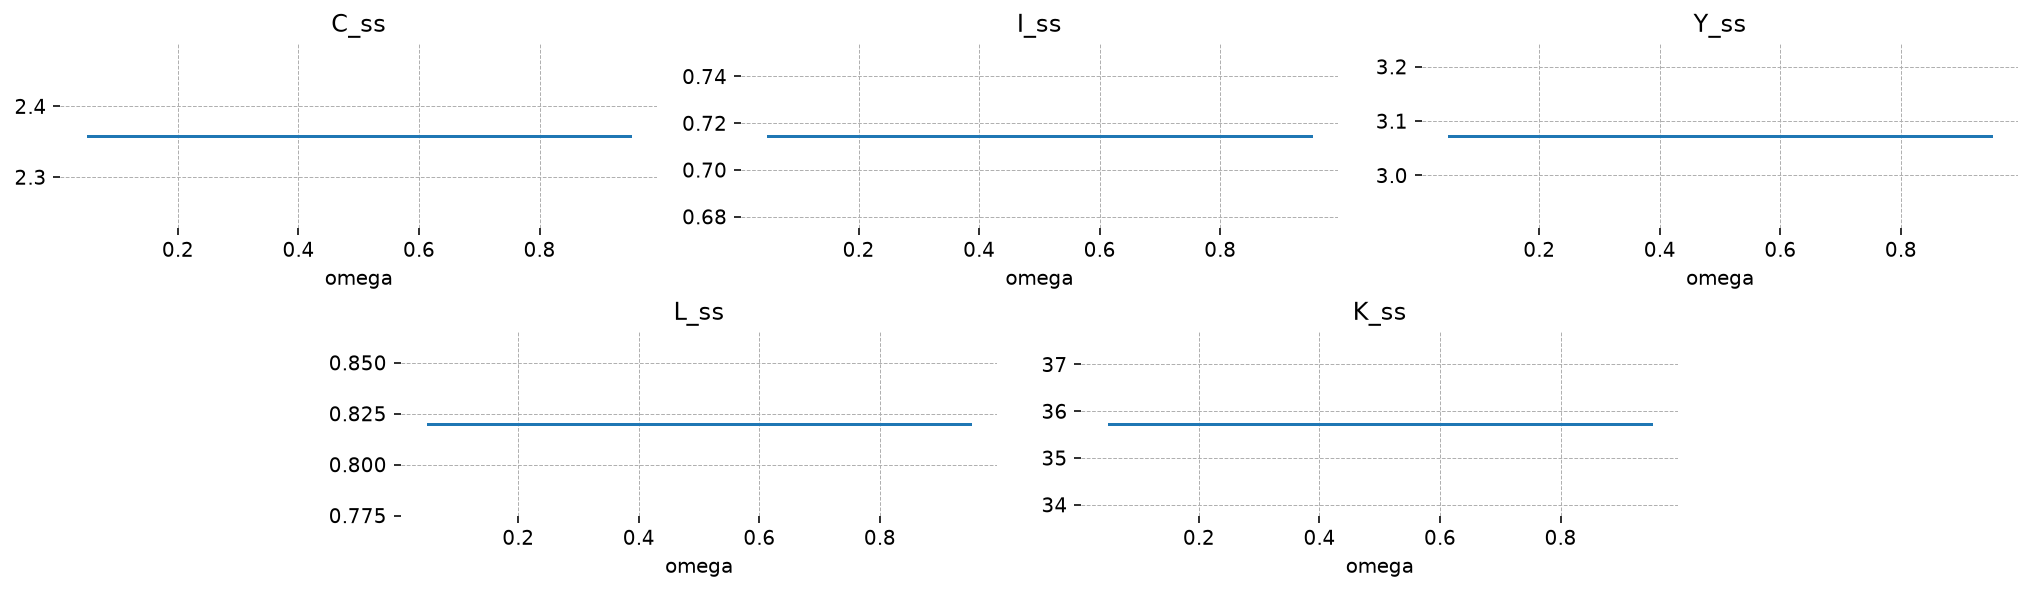

In [28]:
agg_vars = ["C_ss", "I_ss", "Y_ss", "L_ss", "K_ss"]
fig = plt.figure(figsize=(14, 4))
gs, locs = gp.prepare_gridspec_figure(n_cols=3, n_plots=len(agg_vars), figure=fig)
for var, loc in zip(agg_vars, locs, strict=False):
    axis = fig.add_subplot(gs[loc])
    steady_states.set_index("omega")[var].plot(ax=axis, title=var)
plt.show()

For the household variables, we see that as the share of Ricardian households ($\omega$) increases, those households each consume less and work more. This is explained by the pool of capital resources being held by a larger and larger population, who have to share the (fixed!) proceeds. As their size grows, they each have less income from capital rents, so they are forced to btoh cut back on consumption and increase working hours to suppliment their reduced income.

On the non-Ricardian side, effects are minor (notice the y-axis scale). But as the number of non-Ricardian households shrinks, the remaining households have to work more in response to the labor choice of the Ricardian households. Evidently, the increase in working hours by the Ricardians in the face of a change in $\omega$ is slightly less than what is required to maintain the fixed aggregate total working hours, so the non-Ricardians have to pick up the slack. Since they work more, they mechanically also consume more, having nothing else to do with their income.

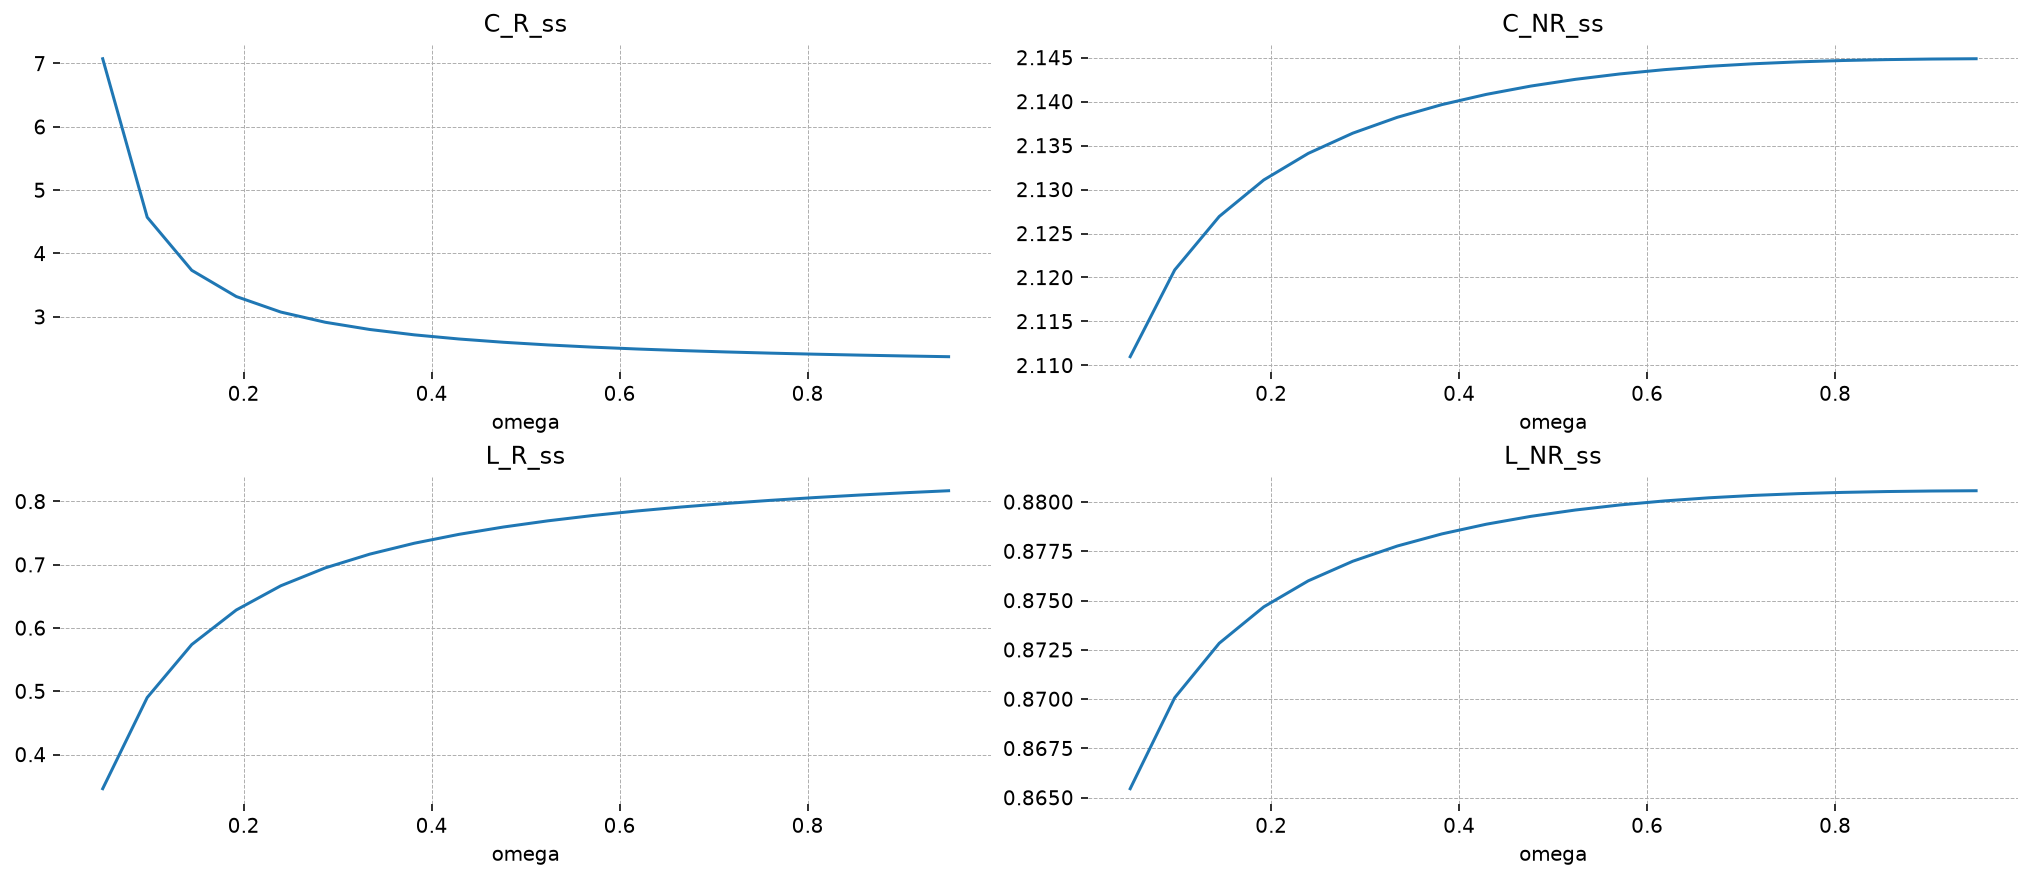

In [29]:
hh_vars = ["C_R_ss", "C_NR_ss", "L_R_ss", "L_NR_ss"]
fig = plt.figure(figsize=(14, 6))
gs, locs = gp.prepare_gridspec_figure(n_cols=2, n_plots=len(hh_vars), figure=fig)
for var, loc in zip(hh_vars, locs, strict=False):
    axis = fig.add_subplot(gs[loc])
    steady_states.set_index("omega")[var].plot(ax=axis, title=var)
plt.show()

## Effect of $\omega$ on Model Dynamics 

To study the effect of changing $\omega$ on model dynamics, we plot impulse response functions for 3 model solutions: mostly non-Ricardian ($\omega = 0.2$), equal ($\omega = 0.5$), and mostly Ricardian ($\omega = 0.8$). 

There are two shocks in this model. One is to the discount factor $\beta$, and one is to total factor productivity (TFP).

### Discount Factor Shock

The discount factor only affects the model through the Ricardian households, because the non-Ricardian problem is static (they don't invest, and thus don't consider the future at all). The shock acts to increase the amount of time discounting Ricardian households do, causing them to view present consumption as more valuable compared to future consumption. The expected effect is to increase present consumption and decrease investment.   

As $\omega$ increases, the efffect of a discount factor shock to aggregate variables ($K, I, Y, C$) becomes larger. The opposite is true in the household variables. As expected, investment decreases, and as a result, capital stock decreases (with some lag). 

When there are more Ricardian households, consumption amonst Ricardian households increases less, and labor decreases less. This is due to the same "share-the-wealth" dynamics noted in the steady state analysis. As before, non-Ricardian households are just "along for the ride", and adjust as required given the choice of the Ricardian households.

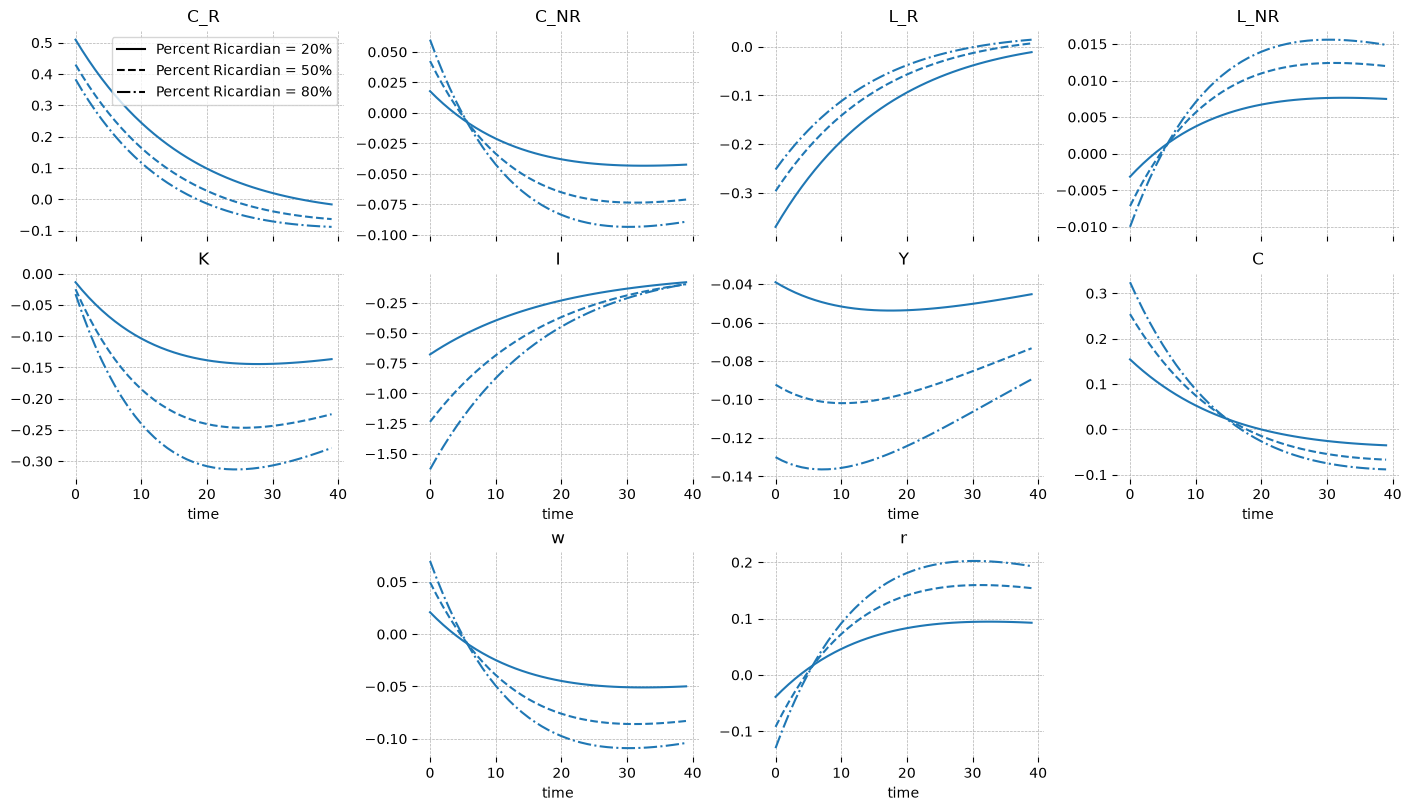

In [30]:
gp.plot_irf(
    {
        f"Percent Ricardian = {omega:0.0%}": ge.impulse_response_function(
            mod,
            shock_size={"epsilon_beta_R": 1.0},
            verbose=False,
            omega=omega,
            steady_state_kwargs={
                "how": "minimize",
                "verbose": False,
                "progressbar": False,
            },
        )
        for omega in [0.2, 0.5, 0.8]
    },
    ["C_R", "C_NR", "L_R", "L_NR", "K", "I", "Y", "C", "w", "r"],
    figsize=(14, 8),
);

### Total Factor Productivity Shock

When TFP is shocked, we expect output to increase, which in turn increases the price of input factors. These are income for the households, who can now consume and invest more. 

The only interesting difference here from the basic model is the reaction of the non-Ricardian households to additional income from wages. Given concave utility of consumption, they have no reason to work more and more, forever. At some point, it will provide more utility to enjoy more leisure rather than additional consumption. We can see that given the parameterization used, the make exactly this choice. Because wages go up, these households can enjoy *both* more consumption and more leisure by cutting back working hours.

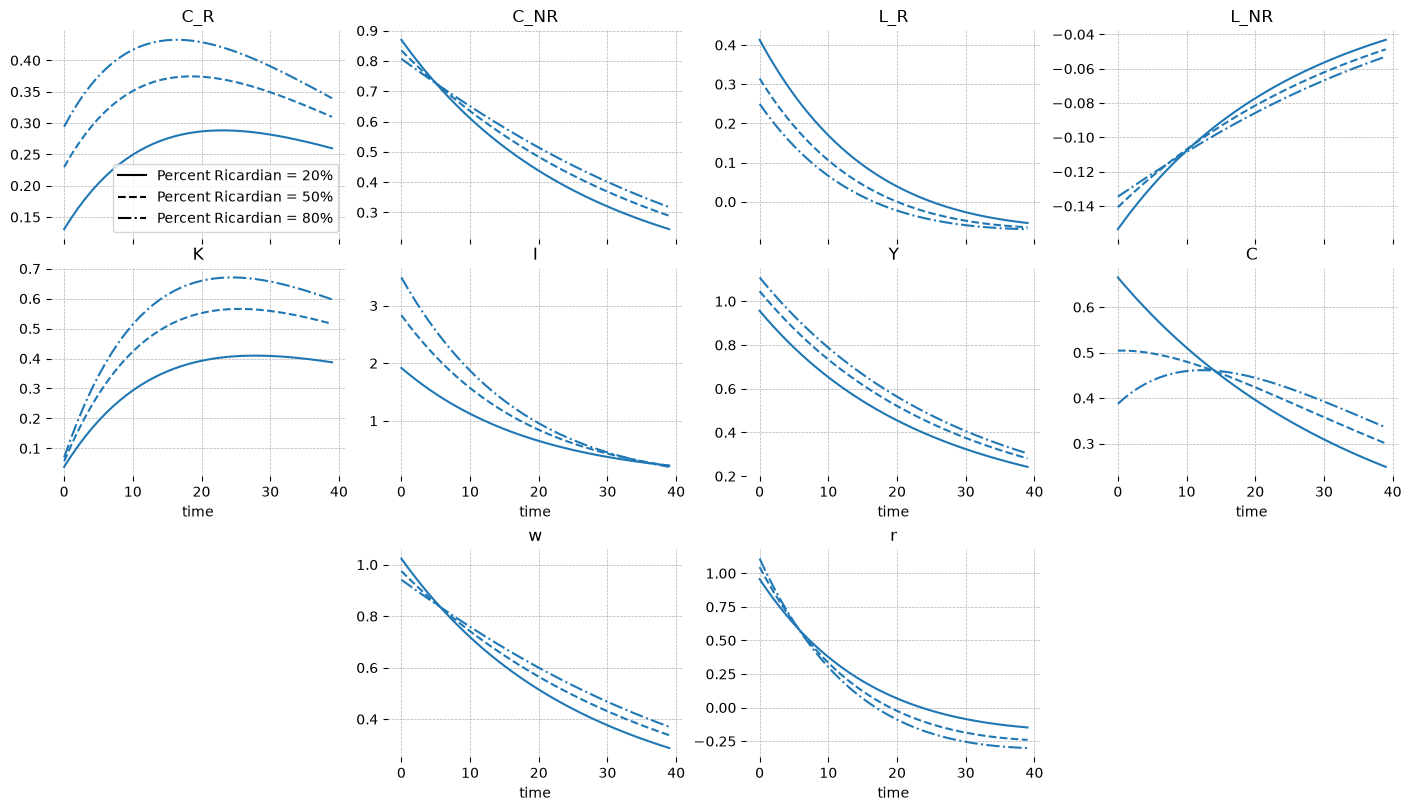

In [31]:
gp.plot_irf(
    {
        f"Percent Ricardian = {omega:0.0%}": ge.impulse_response_function(
            mod,
            shock_size={"epsilon_TFP": 1.0},
            verbose=False,
            omega=omega,
            steady_state_kwargs={
                "how": "minimize",
                "verbose": False,
                "progressbar": False,
            },
        )
        for omega in [0.2, 0.5, 0.8]
    },
    ["C_R", "C_NR", "L_R", "L_NR", "K", "I", "Y", "C", "w", "r"],
    figsize=(14, 8),
);

# An Analytic Version 

We saw previously that this model did not have a tractible steady state because we could not isolate and solve for $L_R$ after substituting everything into the total economic resource constraint. This was because of the awkward powers on $L_R$. A patch for this is switch utility to be linear in labor dispreference. The one-period utility function is now:

$$ u_{x,t} = \frac{C_t^{1 - \sigma_x}}{1 - \sigma_x} - \Theta_x L_{x,t} $$

This functional form isn't totally crazy. It corresponds to a setup where households choose labor particiption at the extensive, rather than the intensive, margin. That is, households will make the binary choice of whether to work or not work. To make this setup work, you have to assume that they get paid their full wage regardless of their choice due to a perfect unemployment insurance scheme operating behind the scenes. There's also no search frictions, and workers can show up to work or not as they please. Must be nice.

In this scheme, the parameter $\Theta$ is a combination of deeper parameters, including total working hours, the probability of choosing to work, and the inverse Frisch elasticity. In gEconpy, parameters are allowed to be defined as combinations of other parameters, so you are allowed to define these deeper parameteres in a `calibration` block and define `Theta_x` as an equation. This is not done here, though -- I just set $\Theta_x = 0$ because I'm lazy.  

## More algebra

Choosing this utility function causes $L_{x,t}$ to drop out of the labor supply curve for each household, and just become:

$$ 
C_{x,t}^{\sigma_x} = \frac{w_t}{\Theta_x} 
$$

So that once wages are known, consumption for both households is known, and aggregate consumption is immediately known:

$$
C = \omega \left ( \frac{w}{\Theta_R} \right ) ^{\frac{1}{\sigma_R}} + (1 - \omega) \left ( \frac{w}{\Theta_N} \right )^{\frac{1}{\sigma_N}}
$$

Plugging this into the total resource constraint:

$$
\begin{aligned}
Y &= C + I \\
N^\alpha L &= \omega \left ( \frac{w}{\Theta_R} \right ) ^{\frac{1}{\sigma_R}} + (1 - \omega) \left ( \frac{w}{\Theta_N} \right )^{\frac{1}{\sigma_N}} + \delta N L
\end{aligned}
$$

Since the labor terms dropped out of the aggregate consumption, we can easily solve this for aggregate labor:

$$
L = \frac{\omega \left ( \frac{w}{\Theta_R} \right ) ^{\frac{1}{\sigma_R}} + (1 - \omega) \left ( \frac{w}{\Theta_N} \right )^{\frac{1}{\sigma_N}}}{N^\alpha - \delta N}
$$

As before, we know the labor choice of the non-Ricardians from their budget constraint:

$$
L_{NR} = \frac{C_{NR}}{w}
$$

So $L_R$ is pinned down from the aggregate labor condition:

$$
L_{R} = \frac{L - (1 - \omega) L_{NR}}{\omega}
$$

And we're done! For specifics, check out the steady state block below

In [32]:
gcn_file = "../GCN Files/RBC_two_household_additive.gcn"
ge.print_gcn_file(gcn_file)

In [33]:
mod = ge.model_from_gcn(gcn_file)

Model Building Complete.
Found:
	18 equations
	18 variables
		The following variables were eliminated at user request:
			TC_t, U_NR_t, U_R_t
		The following "variables" were defined as constants and have been substituted away:
			mc_t
	4 stochastic shocks
		 0 / 4 have a defined prior.
	12 parameters
		 12 / 12 have a defined prior.
	0 parameters to calibrate.
	18 / 18 variables have analytical steady-state values.
		18 user-provided: C_NR_ss, C_R_ss, C_ss, I_ss, K_ss, L_NR_ss, 
                                  L_R_ss, L_ss, TFP_ss, Theta_N_ss, Theta_R_ss, 
                                  Y_ss, lambda_NR_ss, lambda_R_ss, q_ss, r_ss, 
                                  shock_beta_R_ss, w_ss
Model appears well defined and ready to proceed to solving.



Since the steady-state is now analytic, no progress bar pops up.

In [34]:
steady_state = mod.steady_state()
ge.print_steady_state(steady_state)

C_ss                     1.810
C_NR_ss                  1.810
C_R_ss                   1.810
I_ss                     0.549
K_ss                    27.428
L_ss                     0.629
L_NR_ss                  0.743
L_R_ss                   0.571
TFP_ss                   1.000
Theta_N_ss               1.000
Theta_R_ss               1.000
Y_ss                     2.359
lambda_NR_ss             0.411
lambda_R_ss              0.411
q_ss                     0.411
r_ss                     0.030
shock_beta_R_ss          1.000
w_ss                     2.436


You can still check the steady state residuals and gradients, though

In [35]:
mod.evaluate_residual(steady_state, mod.parameters()).sum()

np.float64(2.4185190578869133e-16)

In [36]:
# Check the gradient too, why not
squared_error = pt.sum([eq**2 for eq in mod.equation_tensors()])
error_grad = pt.stack(pt.grad(squared_error, mod.ss_tensors()))
f_grad = pytensor.function([*mod.ss_tensors(), *mod.param_tensors()], error_grad)

f_grad(**steady_state, **mod.parameters())

array([ 2.16073208e-16, -2.47089336e-16, -1.42608317e-16,  1.01506528e-16,
       -5.65901176e-18,  6.08954930e-16,  4.47057075e-16,  4.68736785e-17,
       -2.83320975e-16, -9.06773547e-17, -9.06773547e-17, -1.39260402e-16,
        2.20869605e-16,  2.20914762e-16, -4.51571309e-20, -1.17040761e-17,
       -9.06773547e-17,  4.54830511e-16])

## New effect of $\omega$ on the steady state

As before, we iterate over a sequence of $\omega$ values and plot the results.

In [37]:
results_analyic = []
for omega in omegas:
    ss = mod.steady_state(verbose=False, omega=omega)
    ss["success"] = ss.success
    ss["omega"] = omega
    results_analyic.append(ss)

results_analytic_df = pd.DataFrame(results_analyic)

As before, aggregate variables are not affected by changes in the household composition of the economy. Compared to the CRRA case we studied above (in orange), the new model also has lower steady state values of all variables.

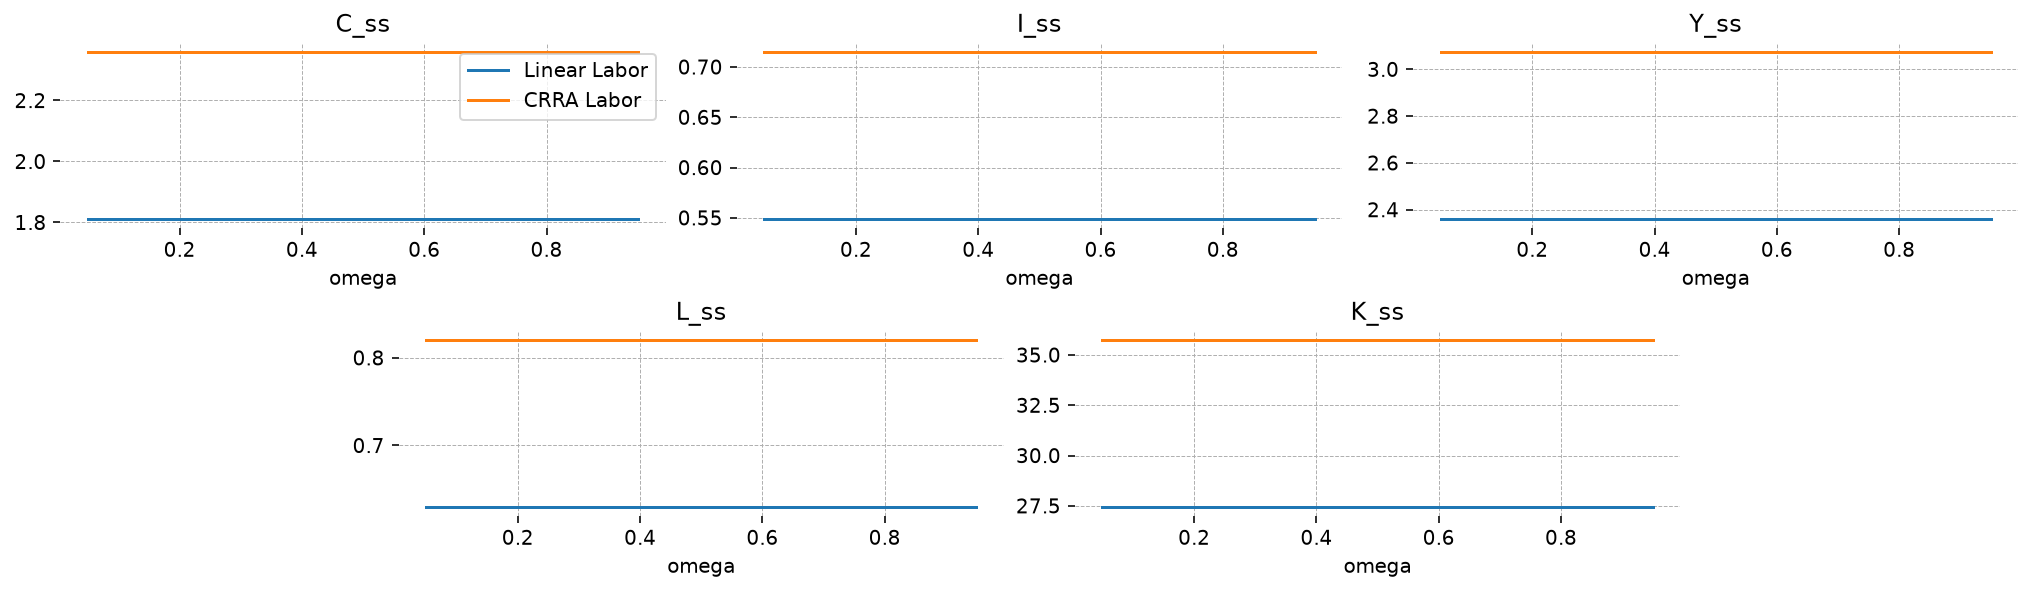

In [38]:
fig = plt.figure(figsize=(14, 4))
gs, locs = gp.prepare_gridspec_figure(n_cols=3, n_plots=len(agg_vars), figure=fig)
for var, loc in zip(agg_vars, locs, strict=False):
    axis = fig.add_subplot(gs[loc])
    results_analytic_df.set_index("omega")[var].plot(ax=axis, title=var, label="Linear Labor")
    steady_states.set_index("omega")[var].plot(ax=axis, color="tab:orange", label="CRRA Labor")

fig.axes[0].legend()
plt.show()

What changes now is that the *household* level variables are also much less responsive! In fact, only $L_R$ is a function of $\omega$. This is actually clear in the algebra above, when we saw that household consumptions in the steady state are completely pinned down by the labor supply curve. So consumption is a function of wages only, which in turn is a function only of aggregate variables, which are not a function of the composition of the economy.

Compared to the the CRRA labor case (orange), $L_R$ is much more responsive to changes in $\omega$.

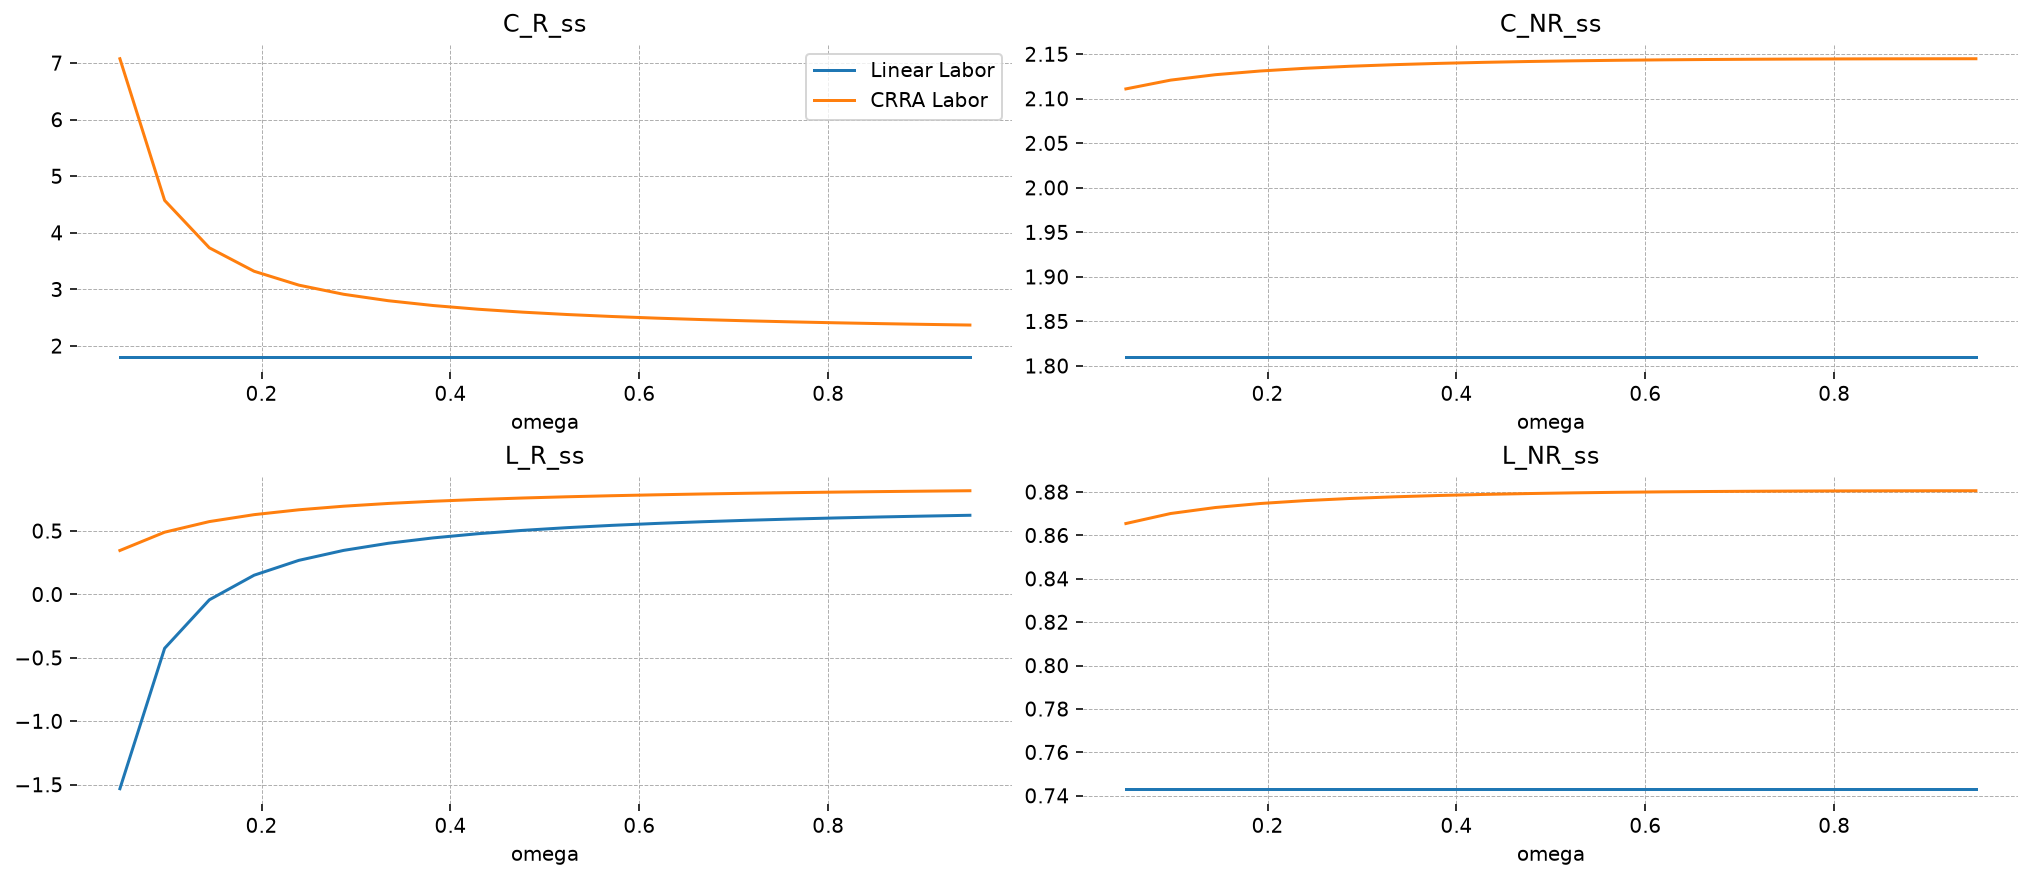

In [39]:
fig = plt.figure(figsize=(14, 6))
gs, locs = gp.prepare_gridspec_figure(n_cols=2, n_plots=len(hh_vars), figure=fig)
for var, loc in zip(hh_vars, locs, strict=False):
    axis = fig.add_subplot(gs[loc])
    results_analytic_df.set_index("omega")[var].plot(ax=axis, title=var, label="Linear Labor")
    steady_states.set_index("omega")[var].plot(ax=axis, color="tab:orange", label="CRRA Labor")

fig.axes[0].legend()
plt.show()

## New effect of $\omega$ on dynamics

In the CRRA case, we saw that when $\omega$ was low, a small group of households were given access to a fixed pot of capital, which made them richer, causing them to consume more and work less. Non-linearities in the utility function with respect to labor made this shifts out of balance with the (fixed!) aggregate variables, so non-Ricardian households were forced to make adjustments in the face of the choices of the Ricardian households.

On the other hand, when labor dispreference is linear, no such tradeoff exists. The choices of the Ricardian households are always balanced with respect to the aggregate variables, so their number doesn't change anything in the broader economy.

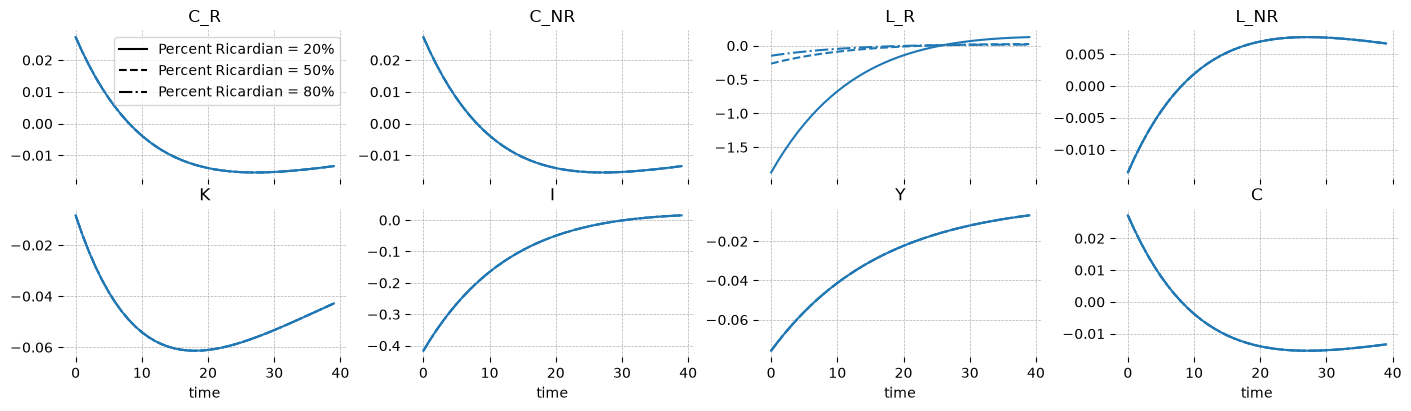

In [40]:
gp.plot_irf(
    {
        f"Percent Ricardian = {omega:0.0%}": ge.impulse_response_function(
            mod,
            shock_size={"epsilon_beta_R": 0.1},
            verbose=False,
            omega=omega,
        )
        for omega in [0.2, 0.5, 0.8]
    },
    ["C_R", "C_NR", "L_R", "L_NR", "K", "I", "Y", "C"],
    figsize=(14, 4),
);

This same logic holds for a TFP shock. Since labor and consumption are disconnected, variation from TFP shocks will not identify variation in any of the model variables, save for $L_{R,t}$.

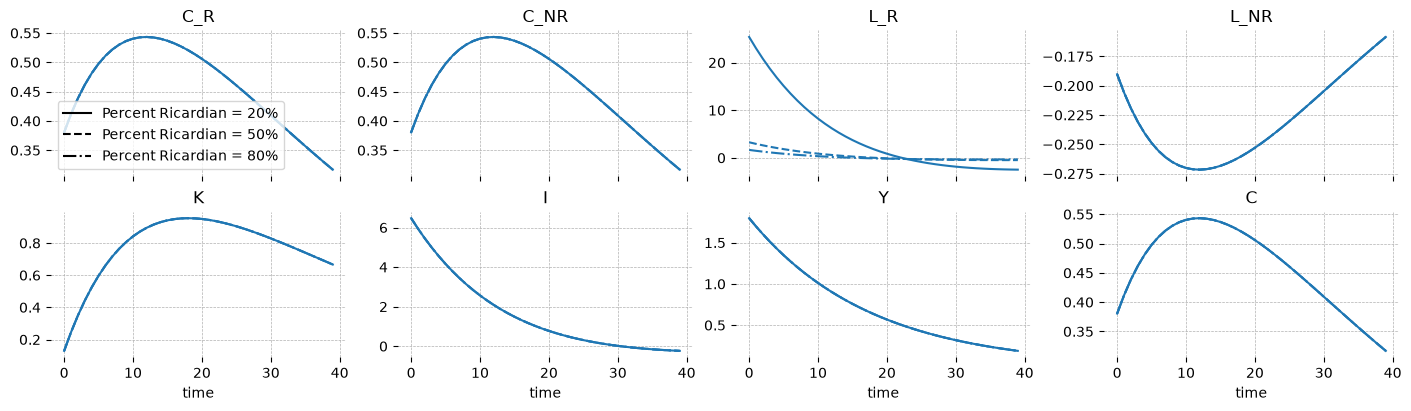

In [41]:
gp.plot_irf(
    {
        f"Percent Ricardian = {omega:0.0%}": ge.impulse_response_function(
            mod,
            shock_size={"epsilon_TFP": 1.0},
            verbose=False,
            omega=omega,
            #             steady_state_kwargs={"how": "root", "verbose": False, "progressbar": False},
        )
        for omega in [0.2, 0.5, 0.8]
    },
    ["C_R", "C_NR", "L_R", "L_NR", "K", "I", "Y", "C"],
    figsize=(14, 4),
);

### Some new shocks!

Since that's kind of a bummer, I added shocks on $\Theta_N$ and $\Theta_R$, the labor dispreference terms. These cuase some reverberations though the economy, the size of which *is* mitigated by $\omega$.

When $\Theta_N$ increases, non-Ricardian households experience more disutility from working, and work less. They also consume less as a result. Wages have to increase to entire them to come to work. Ricardian households benefit from this, working more as well.

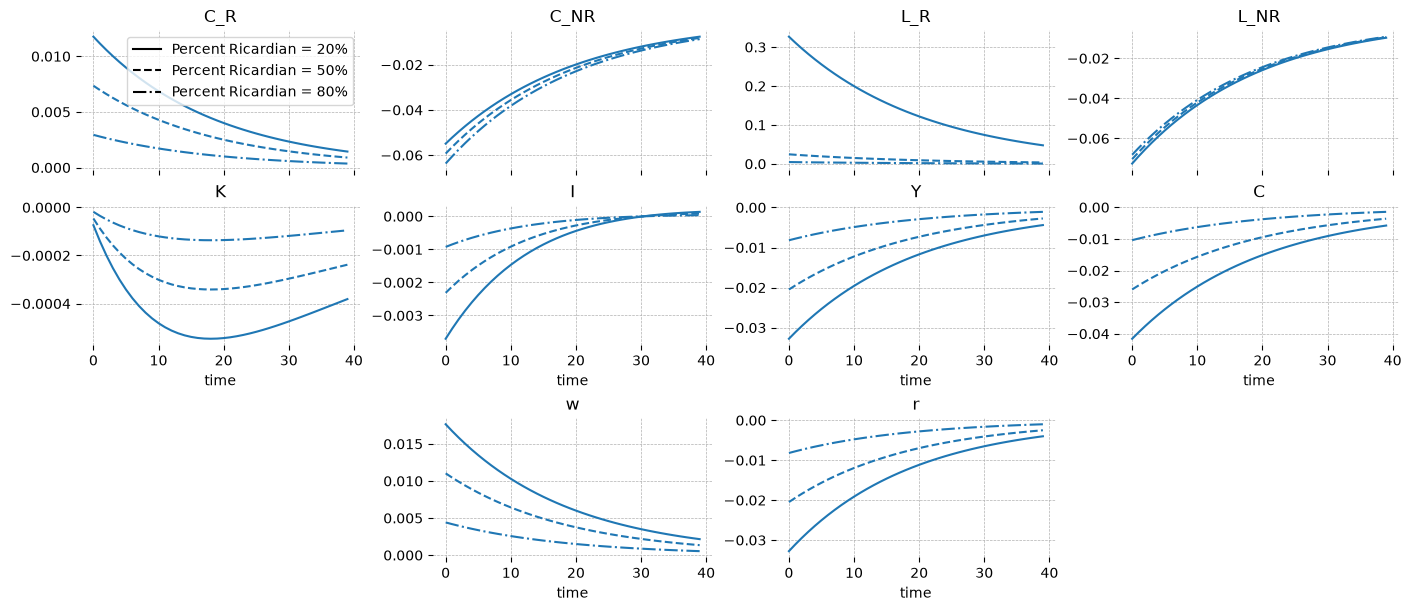

In [42]:
gp.plot_irf(
    {
        f"Percent Ricardian = {omega:0.0%}": ge.impulse_response_function(
            mod,
            shock_size={"epsilon_Theta_N": 0.1},
            verbose=False,
            omega=omega,
            #             steady_state_kwargs={"how": "root", "verbose": False, "progressbar": False},
        )
        for omega in [0.2, 0.5, 0.8]
    },
    ["C_R", "C_NR", "L_R", "L_NR", "K", "I", "Y", "C", "w", "r"],
    figsize=(14, 6),
);

When Ricardian households are the ones who don't want to work ($\Theta_R$ increases), the story is largely the same, but the dynamics are simplier. The non-Ricardian households respond to higher wages by consuming more and working less, increasing their utility. The result is less labor in the econonmy overall, which drives down output. 

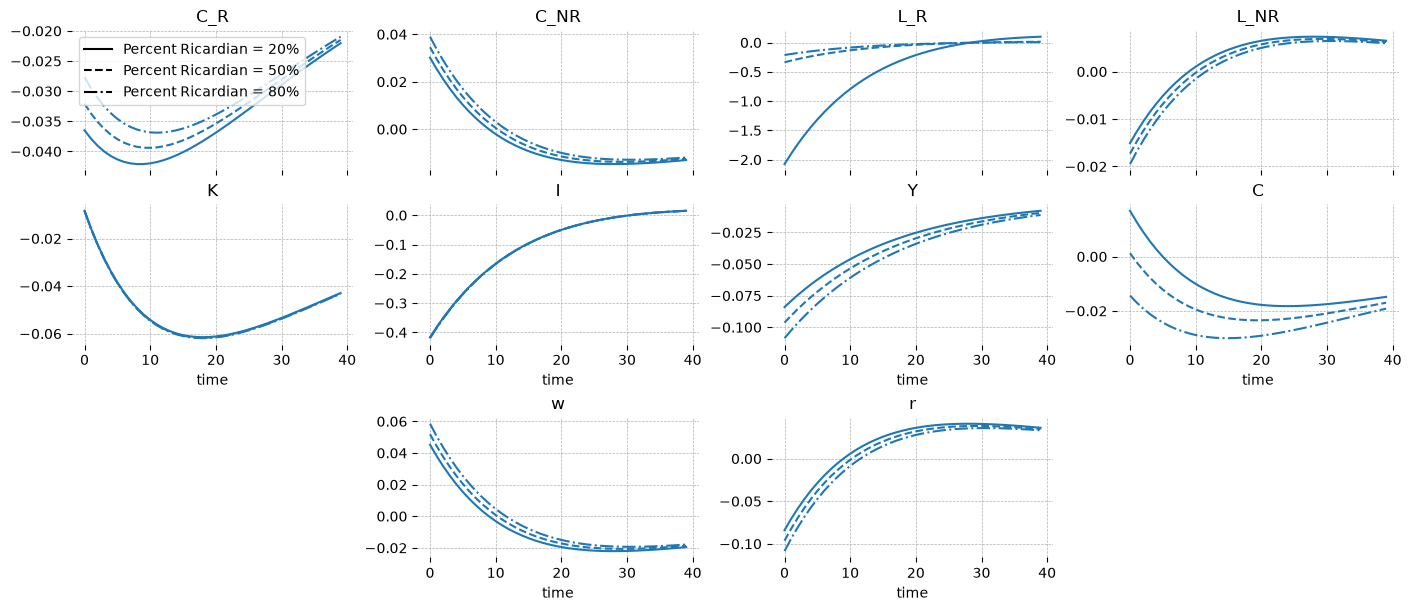

In [43]:
gp.plot_irf(
    {
        f"Percent Ricardian = {omega:0.0%}": ge.impulse_response_function(
            mod,
            shock_size={"epsilon_Theta_R": 0.1},
            verbose=False,
            omega=omega,
            #             steady_state_kwargs={"how": "root", "verbose": False, "progressbar": False},
        )
        for omega in [0.2, 0.5, 0.8]
    },
    ["C_R", "C_NR", "L_R", "L_NR", "K", "I", "Y", "C", "w", "r"],
    figsize=(14, 6),
);

# A Parameter Recovery Exercise

Since the analytical model is, well, analytical, we can fit a Bayesian model to it.

In [44]:
ss_mod = ge.statespace_from_gcn(gcn_file)
deep_params = list(ss_mod.param_dict.keys())

Model Building Complete.
Found:
	18 equations
	18 variables
		The following variables were eliminated at user request:
			TC_t, U_NR_t, U_R_t
		The following "variables" were defined as constants and have been substituted away:
			mc_t
	4 stochastic shocks
		 0 / 4 have a defined prior.
	12 parameters
		 12 / 12 have a defined prior.
	0 parameters to calibrate.
	18 / 18 variables have analytical steady-state values.
		18 user-provided: C_NR_ss, C_R_ss, C_ss, I_ss, K_ss, L_NR_ss, 
                                  L_R_ss, L_ss, TFP_ss, Theta_N_ss, Theta_R_ss, 
                                  Y_ss, lambda_NR_ss, lambda_R_ss, q_ss, r_ss, 
                                  shock_beta_R_ss, w_ss
Model appears well defined and ready to proceed to solving.



Statespace model construction complete, but call the .configure method to finalize.


In [45]:
ss_mod.configure(
    observed_states=["Y", "C", "C_R", "L", "L_R", "w"],
    measurement_error=["Y", "C", "C_R", "L", "L_R", "w"],
    full_shock_covariance=True,
    solver="gensys",
    max_iter=20,
    use_adjoint_gradients=True,
)

                              Model Requirements                              
                                                                              
  Variable          Shape    Constraints                          Dimensions  
 ──────────────────────────────────────────────────────────────────────────── 
  Theta_N           ()                                                  None  
  Theta_R           ()                                                  None  
  alpha             ()                                                  None  
  beta              ()                                                  None  
  delta             ()                                                  None  
  omega             ()                                                  None  
  rho_TFP           ()                                                  None  
  rho_Theta_N       ()                                                  None  
  rho_Theta_R       ()                                                  None  
  rho_beta_R        ()                                                  None  
  sigma_N           ()                                                  None  
  sigma_R           ()                                                  None  
  state_cov         (4, 4)   Positive Semi-Definite   ('shock', 'shock_aux')  
  error_sigma_Y     ()       Positive                                   None  
  error_sigma_C     ()       Positive                                   None  
  error_sigma_C_R   ()       Positive                                   None  
  error_sigma_L     ()       Positive                                   None  
  error_sigma_L_R   ()       Positive                                   None  
  error_sigma_w     ()       Positive                                   None  
                                                                              
 These parameters should be assigned priors inside a PyMC model block before  
                  calling the build_statespace_graph method.                  

## Model definition

This model has 4 shocks. It can be interesting, but difficult, to learn about covariances between shocks. One way to learn these covariances is to define a prior over *covariance matrices*. This can be done in PyMC using an `LKJCholeskyCov` prior. This prior has a parameter $\eta$ that controls shrinkage towards diagonal matrices by making the correlation parmeters more and more concentrated arond zero. So, the higher is $\eta$, the more diagonal your matrices will be. When $\eta = 1$, the correlations are uniform between -1 and 1.

In [46]:
all_priors = ss_mod.param_priors | ss_mod.shock_priors

with pm.Model(coords=ss_mod.coords) as pm_mod:
    ss_mod.to_pymc()
    for var_name in ss_mod.error_states:
        x = pz.maxent(pz.Gamma(), lower=0.01, upper=0.05, plot=False)
        all_priors[f"error_sigma_{var_name}"] = x
        x.to_pymc(name=f"error_sigma_{var_name}")

    chol, *_ = pm.LKJCholeskyCov("state_chol", n=4, eta=6, sd_dist=pm.HalfNormal.dist(sigma=0.05))
    cov = pm.Deterministic("state_cov", chol @ chol.T, dims=["shock", "shock_aux"])

## Generate data using draws from the prior

In [47]:
true_params, data, prior = ge.data_from_prior(ss_mod, pm_mod, random_seed=rng)

Sampling: [Theta_N, Theta_R, alpha, beta, delta, error_sigma_C, error_sigma_C_R, error_sigma_L, error_sigma_L_R, error_sigma_Y, error_sigma_w, obs, omega, rho_TFP, rho_Theta_N, rho_Theta_R, rho_beta_R, sigma_N, sigma_R, state_chol]


Sampling: [prior_combined]


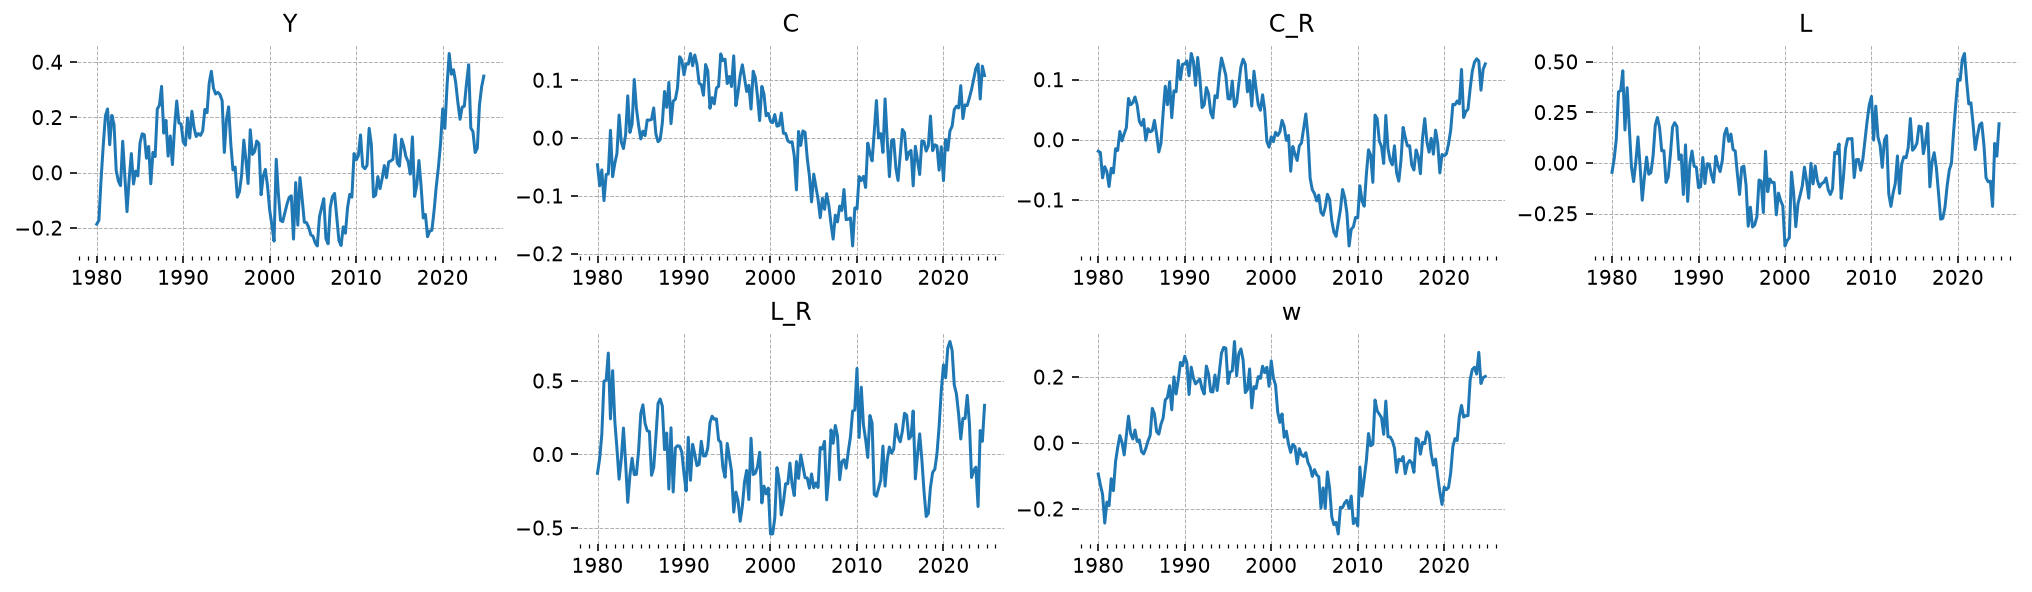

In [48]:
gp.plot_timeseries(data, ss_mod.observed_states);

## Sampling

For MCMC, we use Normalizing Flow (Fisher-Adaptive) NUTS, implemented in Nutpie.

In [49]:
with pm_mod:
    ss_mod.build_statespace_graph(
        data,
        add_norm_check=True,
        add_solver_success_check=True,
    )
    idata = pm.sample(nuts_sampler="nutpie")

NUTS[nutpie]: [beta, delta, sigma_R, Theta_R, rho_beta_R, rho_Theta_R, Theta_N, sigma_N, rho_Theta_N, alpha, rho_TFP, omega, error_sigma_Y, error_sigma_C, error_sigma_C_R, error_sigma_L, error_sigma_L_R, error_sigma_w, state_chol]


## Sampling Diagnostics

Sampling proceeds well. There are few divergences, good energy, and high effective samples.

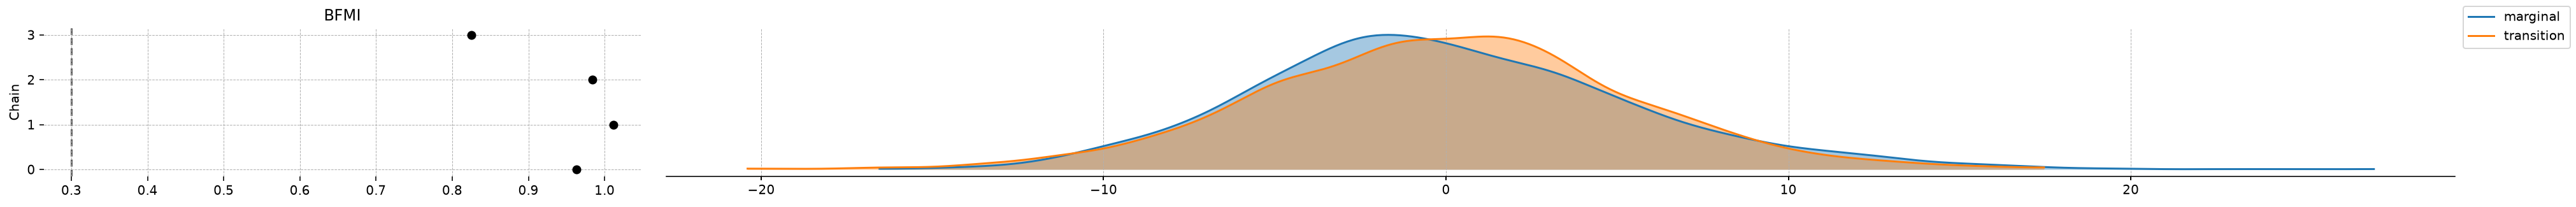

In [50]:
az.plot_energy(idata)

In [51]:
az.summary(idata, var_names=deep_params)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Theta_N,2.3,1.6,0.51,5.3,604,670,1.01,0.06,0.051
Theta_R,2.7,1.8,0.6,6.1,697,635,1.01,0.057,0.037
alpha,0.427,0.039,0.37,0.49,1614,1430,1.00,0.00097,0.00073
beta,0.9733,0.0081,0.96,0.99,1652,1555,1.00,0.0002,0.00016
delta,0.0291,0.0074,0.018,0.041,2726,2211,1.00,0.00014,0.00015
omega,0.757,0.091,0.6,0.88,488,678,1.01,0.004,0.0023
rho_TFP,0.9221,0.028,0.87,0.96,3425,3087,1.00,0.00047,0.00044
rho_Theta_N,0.73,0.159,0.42,0.93,3846,3134,1.00,0.0027,0.0025
rho_Theta_R,0.86,0.04,0.79,0.92,2702,2285,1.00,0.00077,0.00064
rho_beta_R,0.762,0.063,0.66,0.86,1388,1001,1.00,0.0017,0.00092


## Posteriors

We can see that we recover most of the true parameter values. $\Theta_N$, $\Theta_R$, and $\rho_{\Theta_N}$ are not identified. This might be a function of the time series we chose to show to the model, as we omitted $L_{NR}$.

This isn't actually a problem perse, but it does put more pressure on us to choose priors that make sense. We should always still like to incorporate uncertainty about the value of these parameters. This is _especially_ true when the data isn't informative! We certainly don't believe that these parameters have fixed values at 1.0, so it's better that our outputs take into account what values they *could* take on.

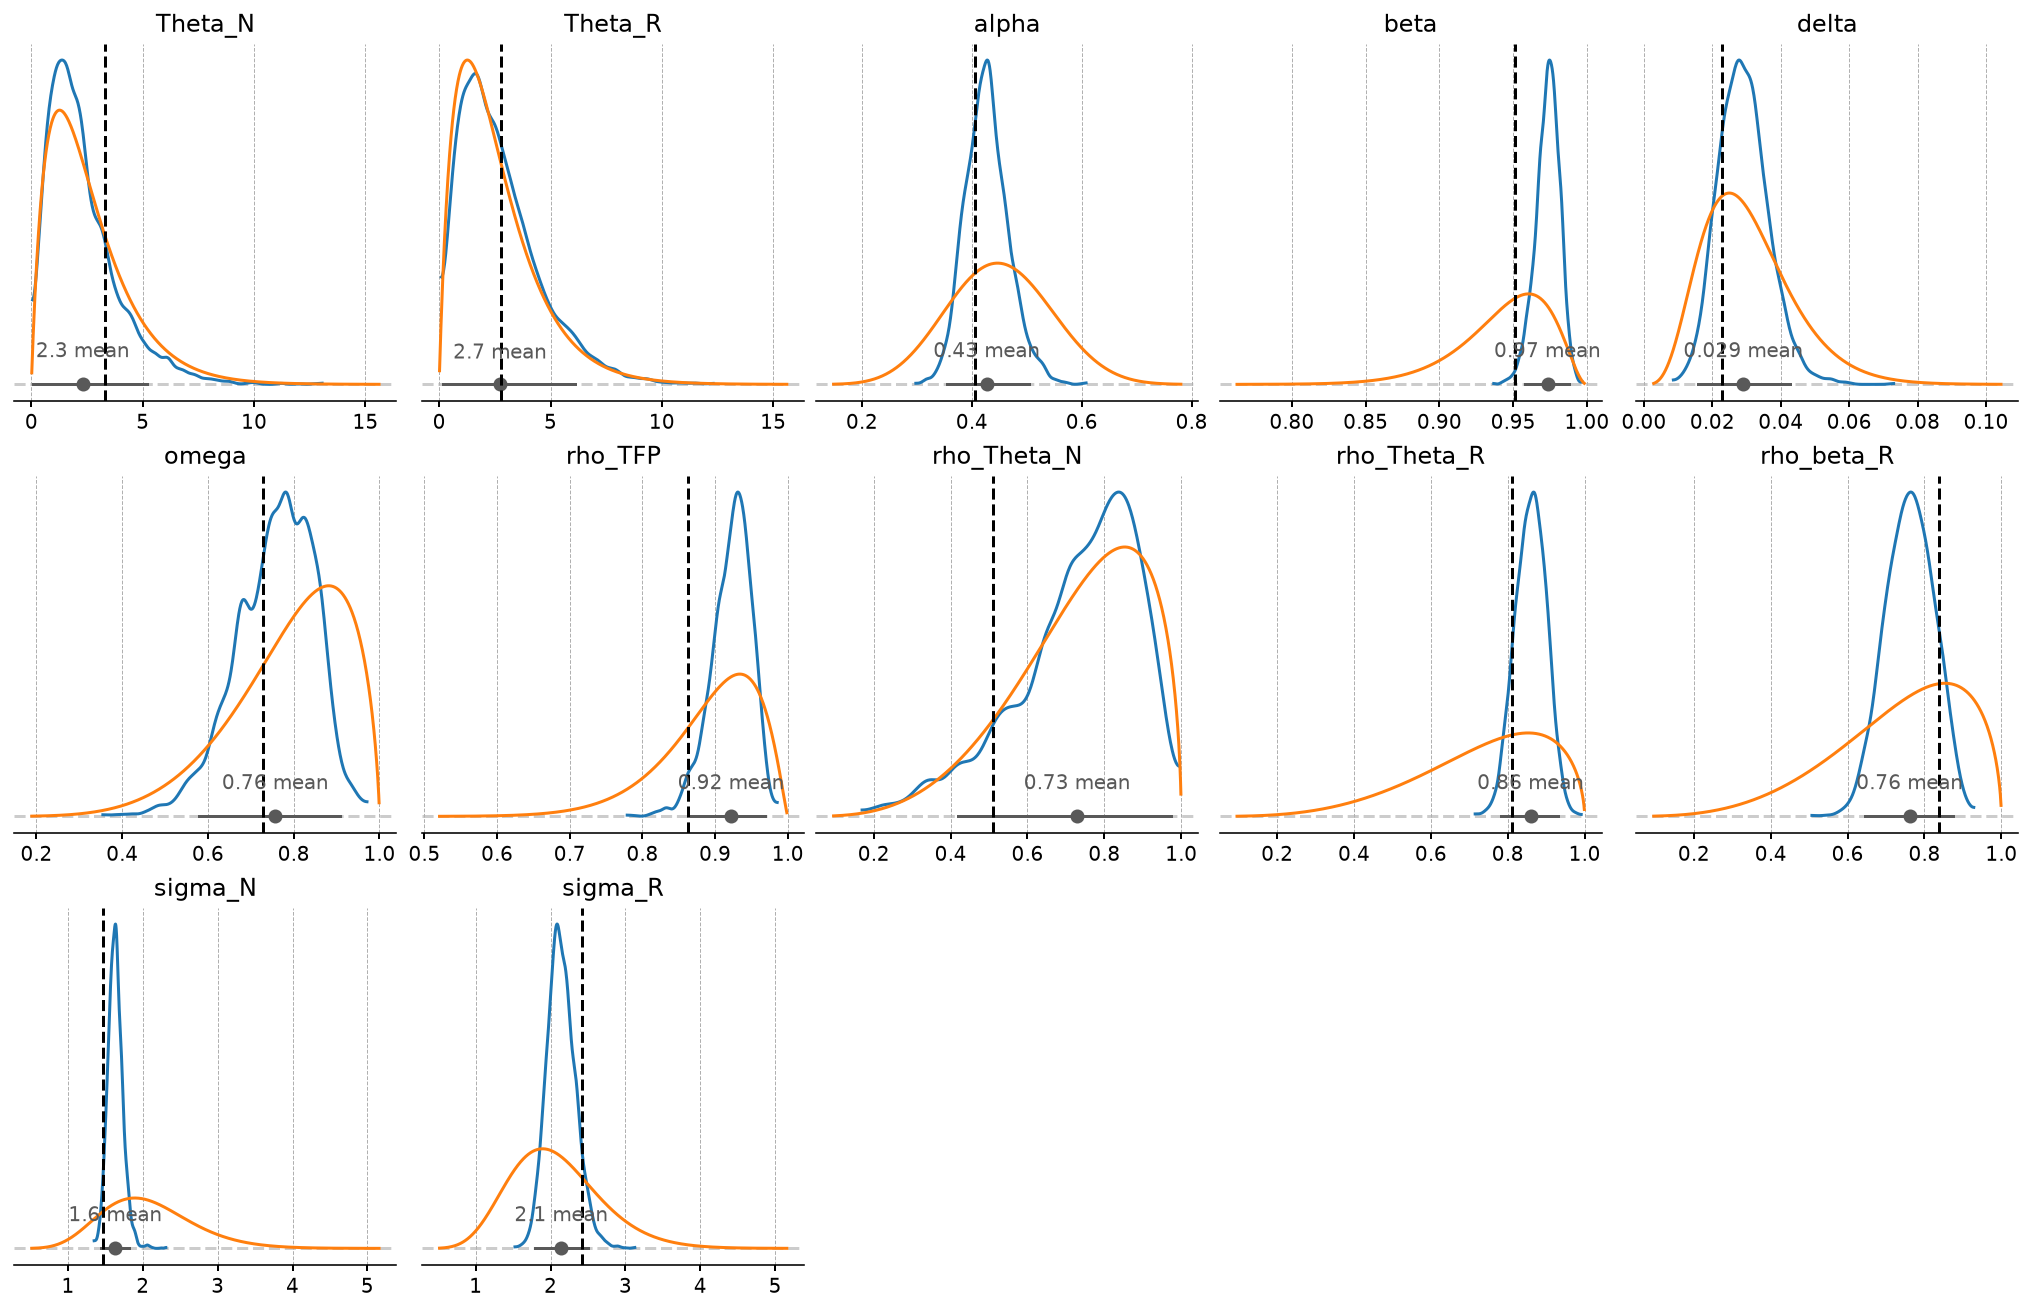

In [52]:
fig = gp.plot_posterior_with_prior(idata, var_names=deep_params, prior_dict=all_priors)
axes_by_title = {axis.get_title(): axis for axis in fig.axes}
for param in deep_params:
    axes_by_title[param].axvline(true_params[param].item(), color="k", ls="--")

It's also important remember that the posterior is a high dimensional object. When we look at the plots like those above, we're looking at *marginal distributions*. These don't tell the entire story, because there could be complex correlation structure between the individual parameter dimensions in the posterior. 

Looking at a **corner plot** can reveal some of that structure, by plotting each pair of parameteters. We see for example a banana-shaped relationship between $\omega$ and $\Theta_R$, which suggets that these parameters are highly coupled. There is also a strong positive correlation between $\delta$ and $\beta$

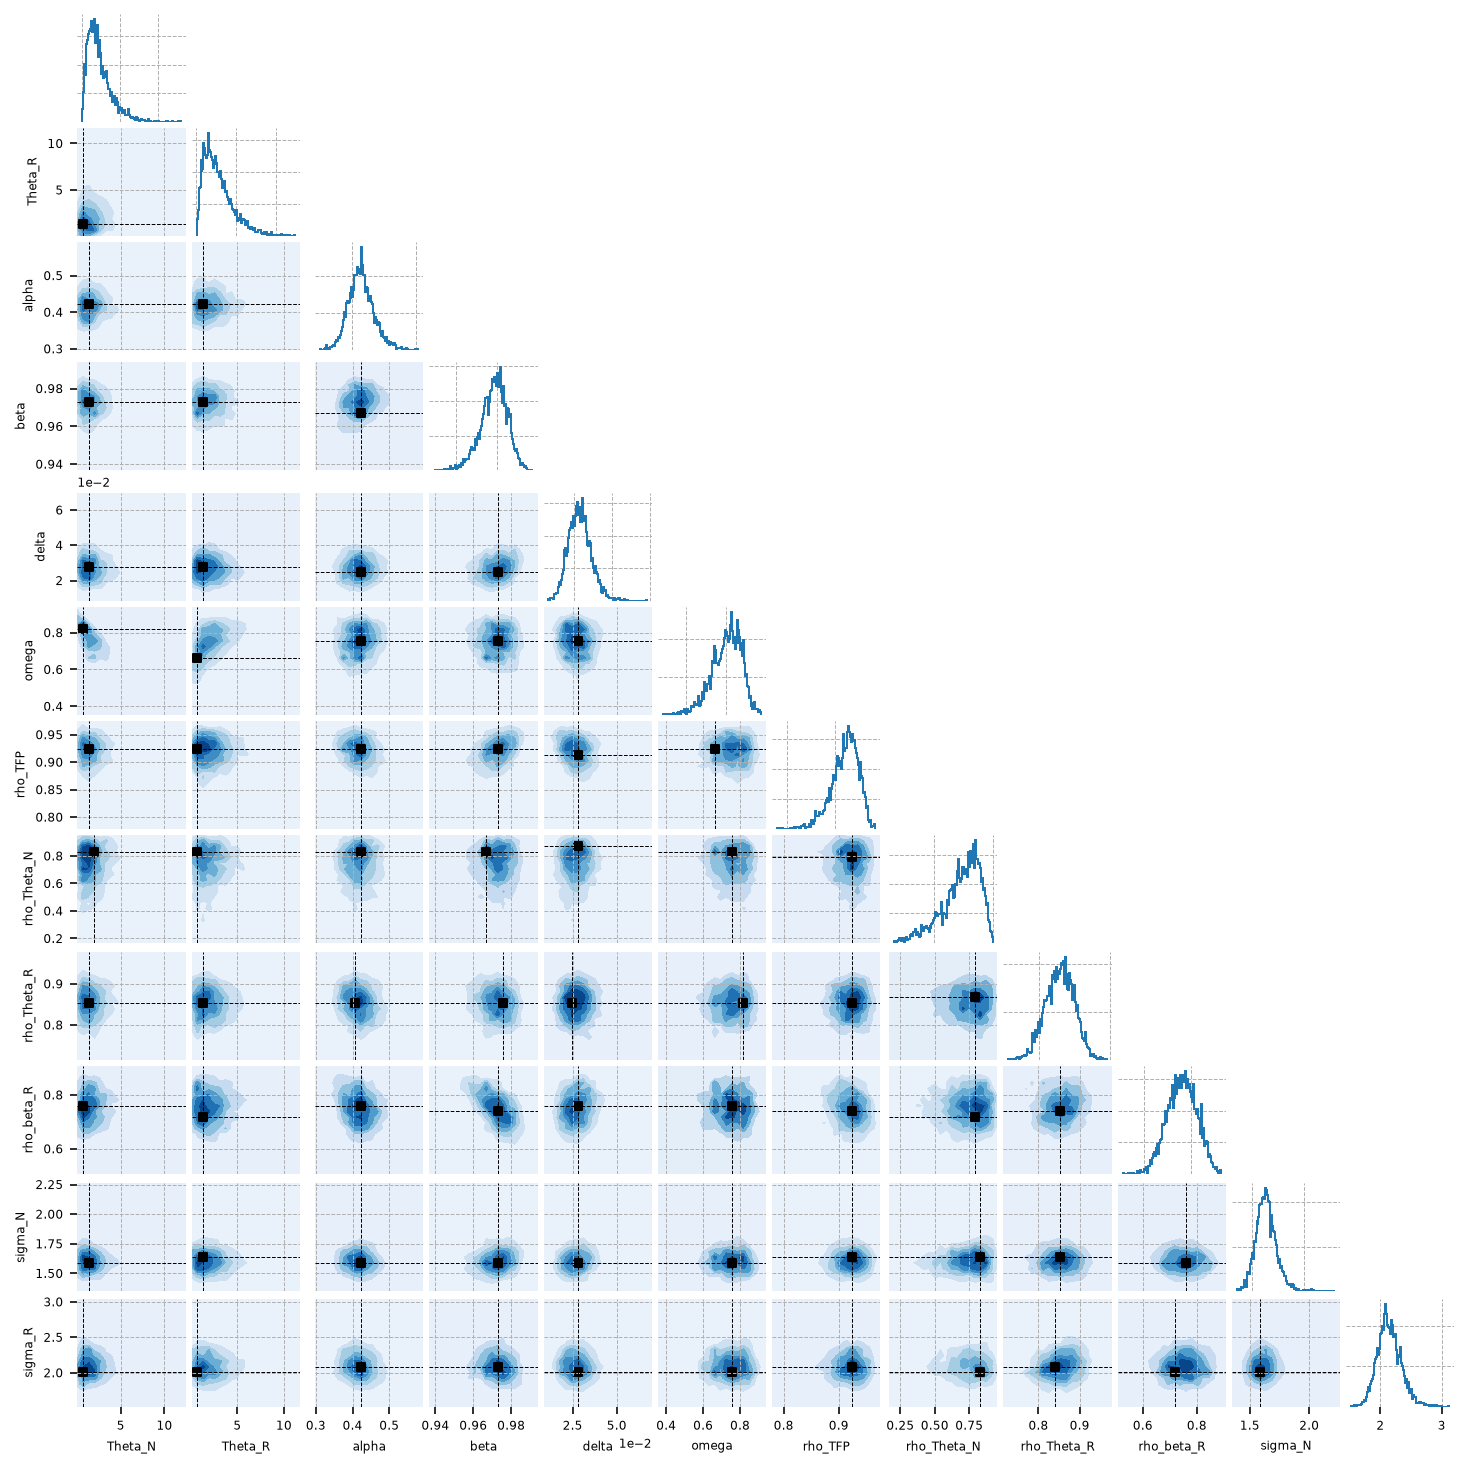

In [53]:
fig = gp.plot_corner(
    idata,
    var_names=deep_params,
    figure_kwargs={"figsize": (10, 10), "dpi": 144, "layout": "constrained"},
);

We can also look at the learned correlatons between the shocks. We see that in the sampled data, there was a positive correlation between TFP and $\Theta_R$ shocks, which was recovered in the posterior. The negative correlation between $\Theta_R$ and $\Theta_N$ was not found, though. This is consistent with $\Theta_N$ itself being unidentified.

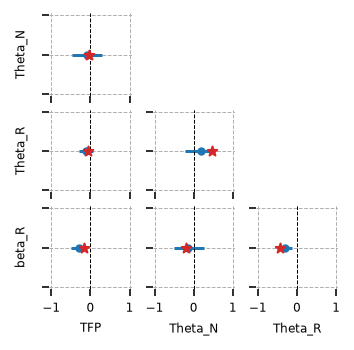

In [54]:
from itertools import product

fig = gp.plot_estimated_matrix(
    idata,
    ss_mod,
    matrix_name="state_chol_corr",
    subplot_kwargs={
        "figsize": (3, 3),
        "dpi": 144,
        "sharex": True,
        "sharey": True,
        "subplot_kw": {"aspect": "equal"},
    },
)
true_corr = true_params["state_chol_corr"].values
for (i, j), axis in zip(product([0, 1, 2, 3], [0, 1, 2, 3]), fig.axes, strict=False):
    if axis.get_visible():
        axis.scatter(true_corr[i, j], 0, c="tab:red", marker="*", s=25, zorder=100)
plt.show()

# Post-Estimation

In [55]:
cond_post = ss_mod.sample_conditional_posterior(idata, random_seed=rng)

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


## Filtered Observed States

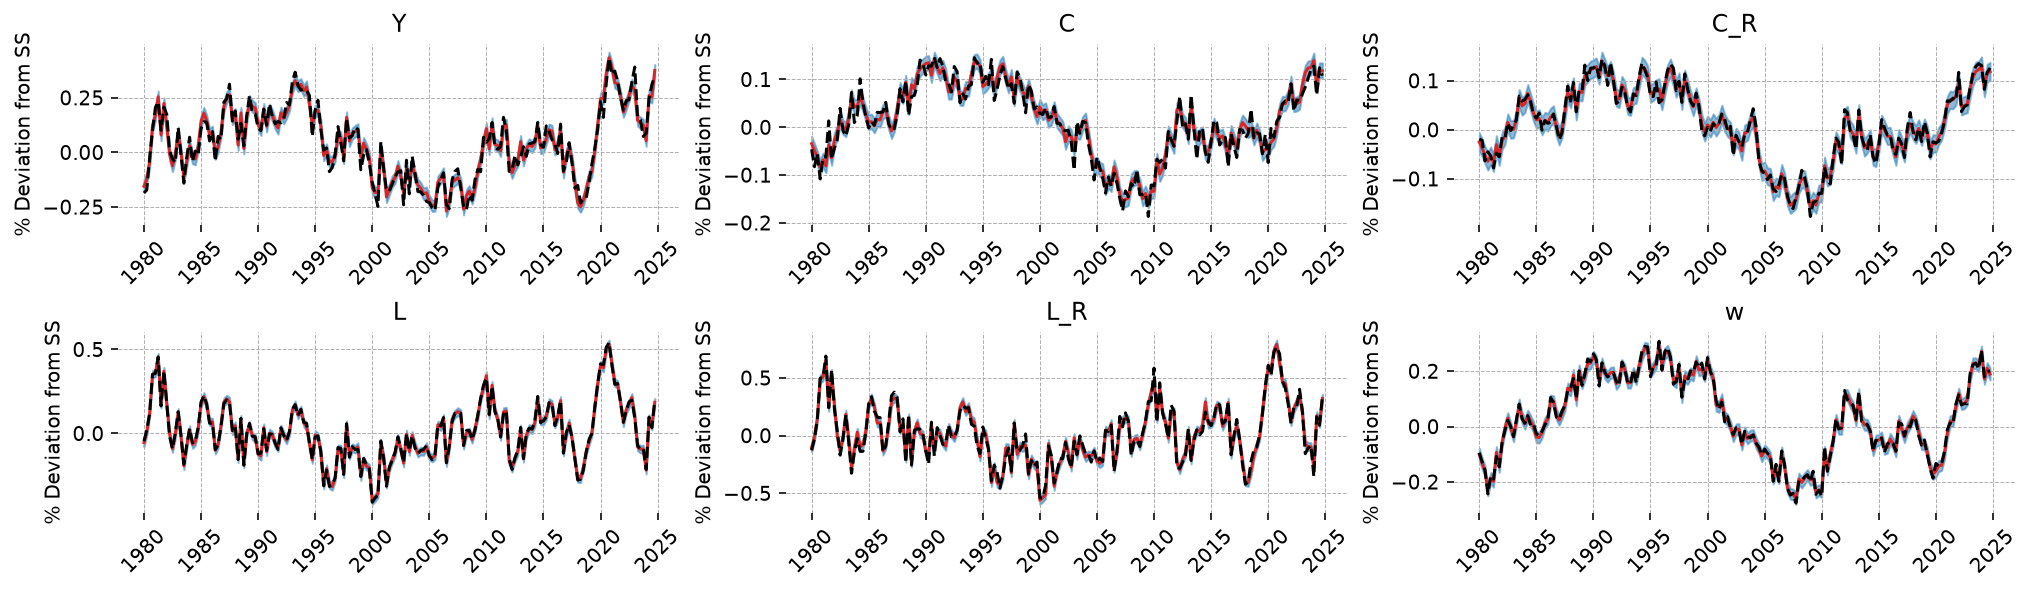

In [56]:
fig = gp.plot_kalman_filter(
    cond_post,
    data,
    kalman_output="smoothed",
    vars_to_plot=data.columns,
    n_cols=3,
    figsize=(14, 4),
);

## Filtered Unobserved States

In [57]:
idx = true_params["param_idx"].item()
unobserved_data = (
    prior.unconditional_prior.sel(chain=0, draw=idx)
    .to_dataset()
    .to_dataframe()["prior_latent"]
    .unstack("state")
    .droplevel(axis=0, level=1)
    .drop_duplicates()
)

Although the model was not shown data for a non-ricardian households, it is able to faithfully recover these time series.

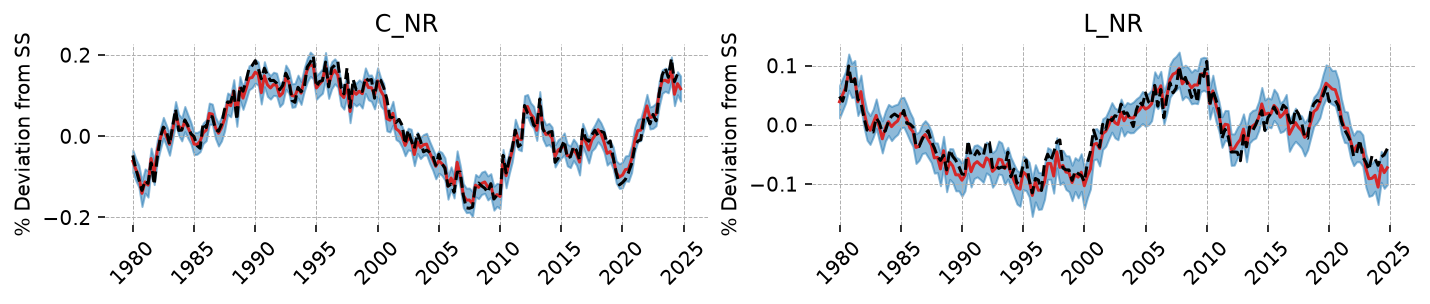

In [58]:
fig = gp.plot_kalman_filter(
    cond_post,
    unobserved_data,
    kalman_output="smoothed",
    vars_to_plot=["C_NR", "L_NR"],
    n_cols=3,
    figsize=(14, 2),
);

We can see that the Kalman Filter also recovers the unobserved shock series: TFP, $\Theta_R$ and $\beta_R$. As noted twice already, it fails to recover $\Theta_N$.

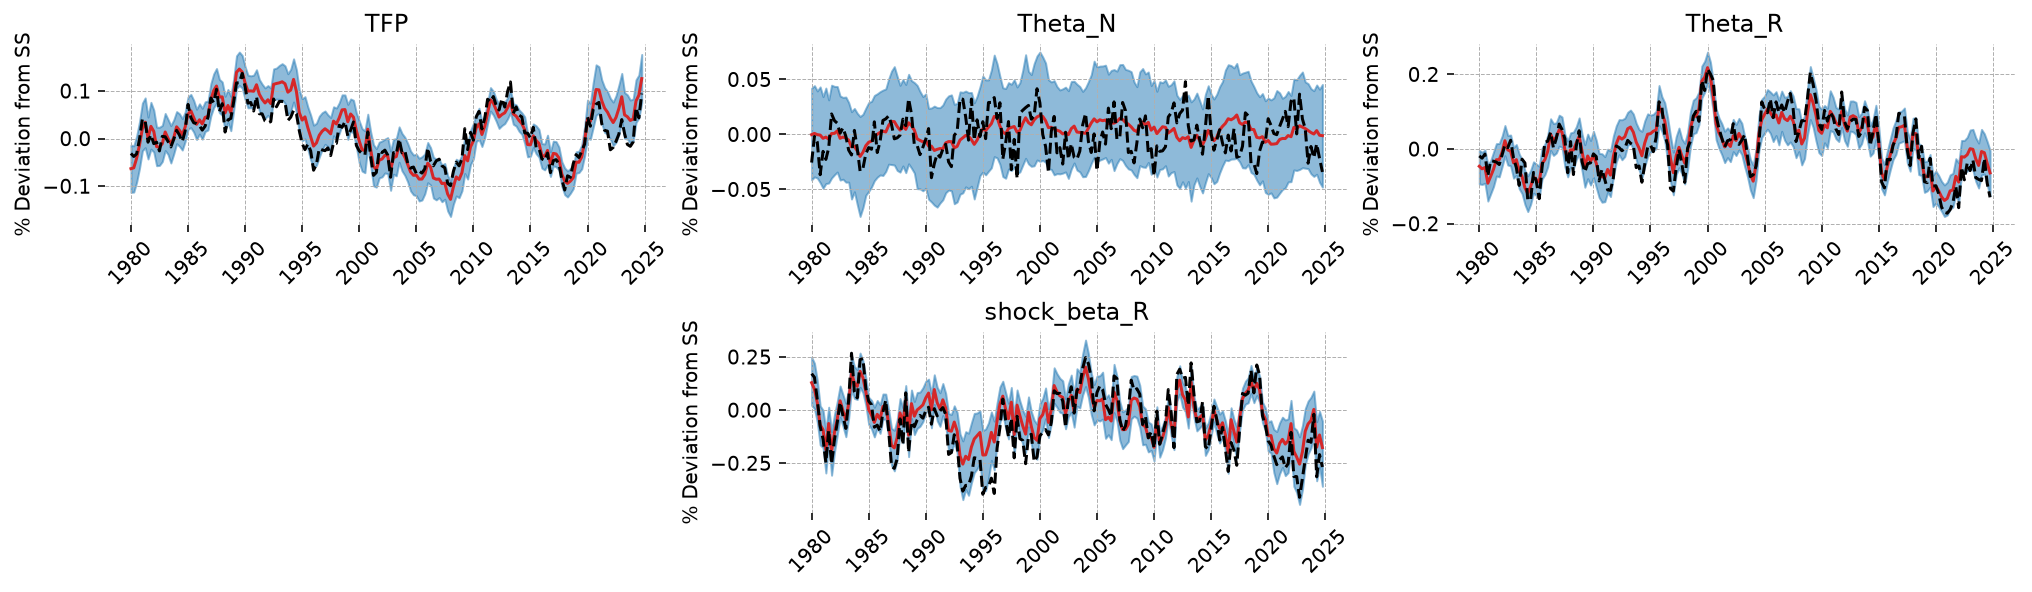

In [59]:
fig = gp.plot_kalman_filter(
    cond_post,
    unobserved_data,
    kalman_output="smoothed",
    vars_to_plot=["TFP", "Theta_N", "Theta_R", "shock_beta_R"],
    n_cols=3,
    figsize=(14, 4),
);

## Impulse Response Functions

We conclude by plotting impulse response functions over selected states. Unlike the IRFs we looked at at the beginning of this notebook, these incorporate uncertainty about the true parameter values.

In [60]:
shock_size = np.zeros(ss_mod.k_posdef)

idx = ss_mod.shock_names.index("epsilon_TFP")
shock_size[idx] = 0.1

irf = ss_mod.impulse_response_function(idata, n_steps=40, shock_size=shock_size, random_seed=rng)

Sampling: []


In [61]:
def plot_irf(irf, vars_to_plot, n_cols=2, figsize=(14, 8), dpi=144, title=None):
    n_plots = len(vars_to_plot)
    n_cols = min(n_plots, n_cols)
    fig = plt.figure(figsize=figsize, dpi=dpi, layout="constrained")
    gs, locs = gp.prepare_gridspec_figure(n_cols=n_cols, n_plots=n_plots, figure=fig)

    data = irf.irf.sel(state=vars_to_plot)

    mu = data.mean(dim=["chain", "draw"])
    hdi = az.hdi(data)
    time = mu.time

    for variable, loc in zip(vars_to_plot, locs, strict=False):
        axis = fig.add_subplot(gs[loc])
        axis.plot(time, mu.sel(state=variable))
        axis.fill_between(time, *hdi.sel(state=variable).values.T, alpha=0.2)
        axis.set_title(variable)
    if title:
        fig.suptitle(title)

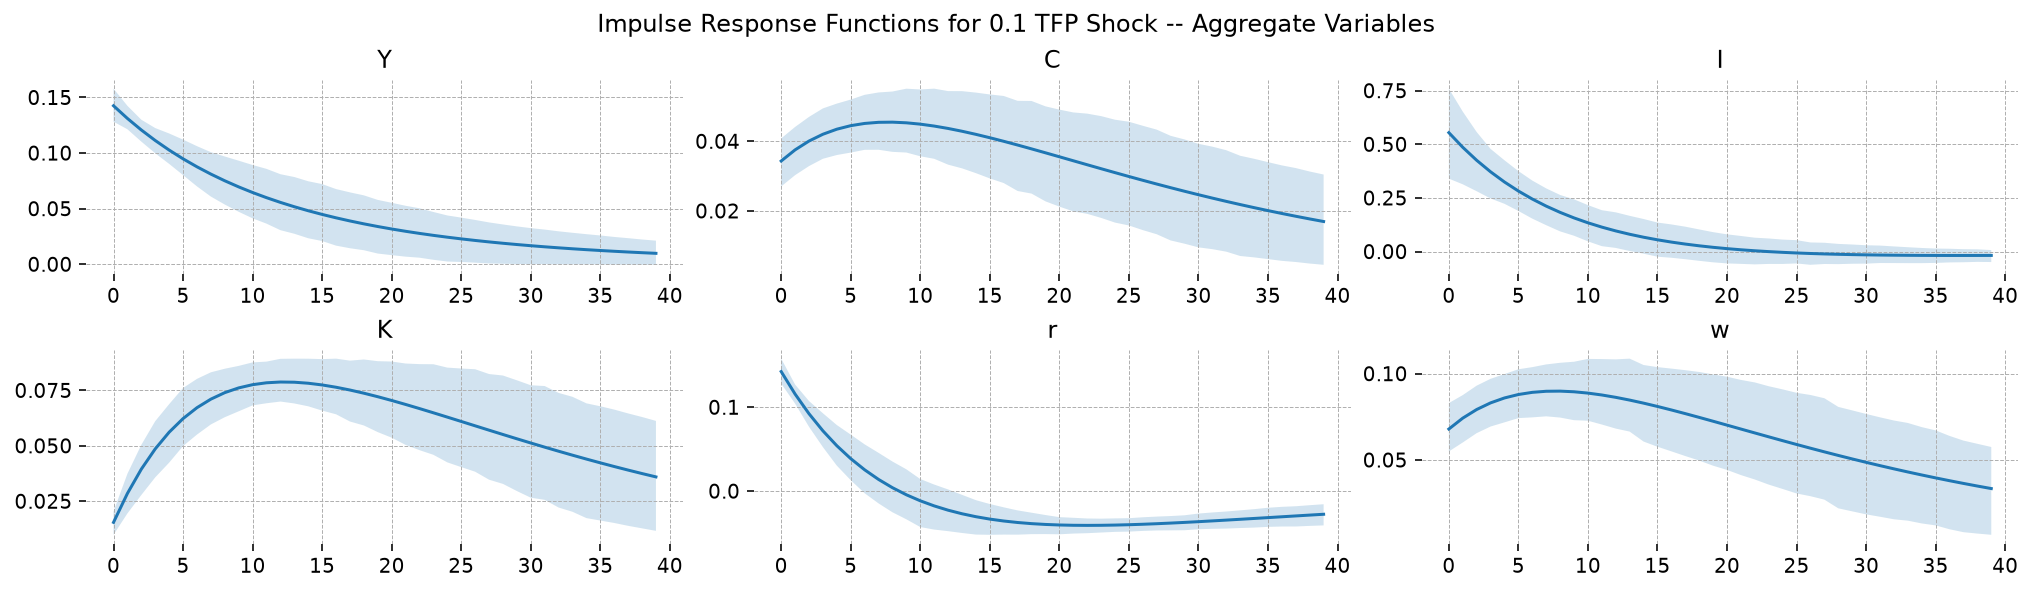

In [62]:
plot_irf(
    irf,
    ["Y", "C", "I", "K", "r", "w"],
    n_cols=3,
    figsize=(14, 4),
    title="Impulse Response Functions for 0.1 TFP Shock -- Aggregate Variables",
)

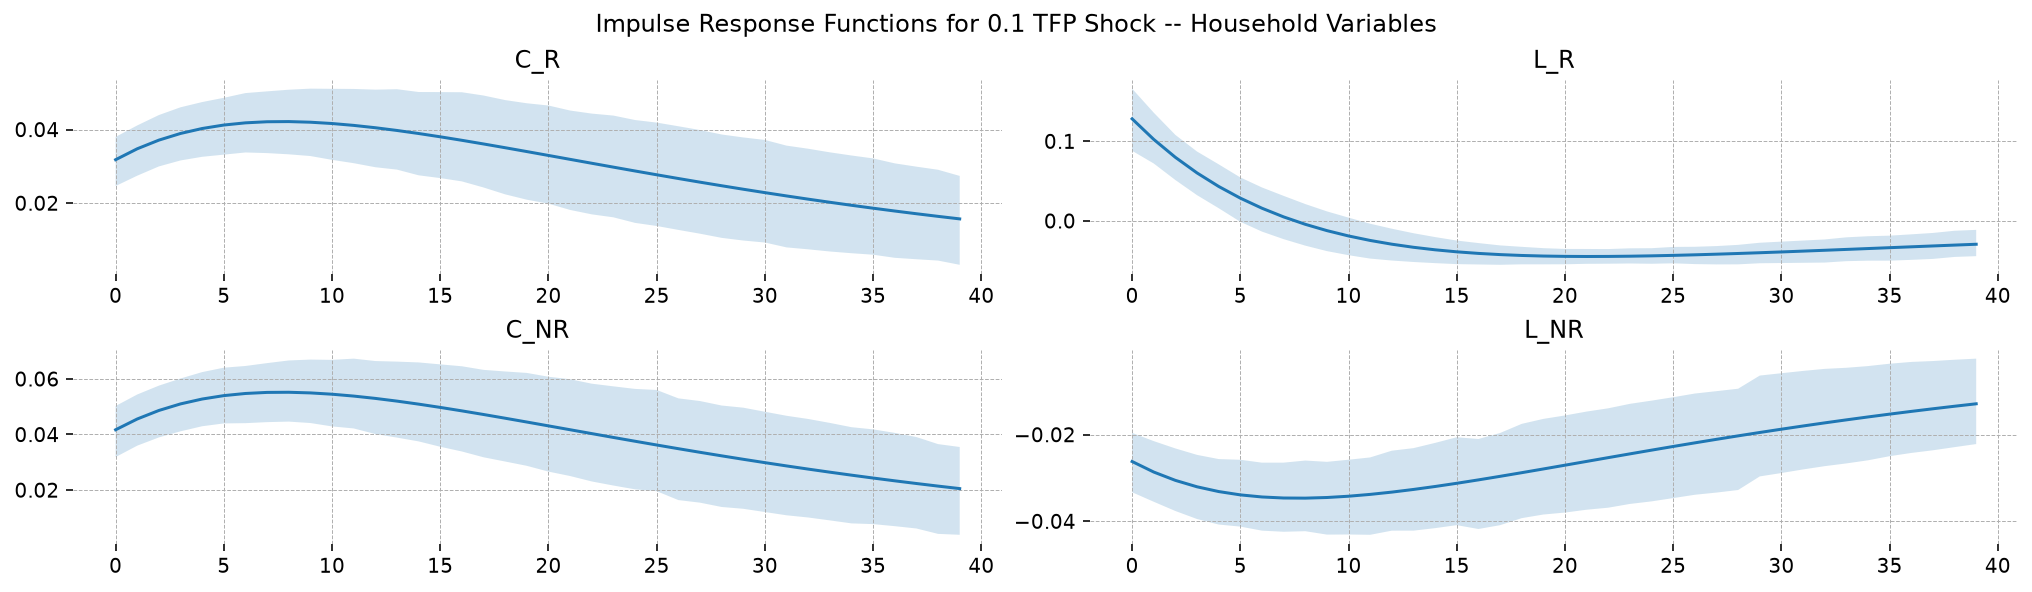

In [63]:
plot_irf(
    irf,
    ["C_R", "L_R", "C_NR", "L_NR"],
    n_cols=2,
    figsize=(14, 4),
    title="Impulse Response Functions for 0.1 TFP Shock -- Household Variables",
)

# Authors

- Authored by Jesse Grabowski in March 2025 
- Updated by Jesse Grabowski in March 2026
- Updated by Jesse Grabowski in September 2026


# Watermark

In [64]:
%load_ext watermark
%watermark -n -u -v -iv -w -p gEconpy

Last updated: Thu, 17 Sep 2026

Python implementation: CPython
Python version       : 3.12.14
IPython version      : 9.17.1

gEconpy: 2.2.1.dev37+g2d175e5c4.d20260916

arviz     : 1.3.0
gEconpy   : 2.2.1.dev37+g2d175e5c4.d20260916
matplotlib: 3.11.1
numpy     : 2.4.6
pandas    : 3.0.5
preliz    : 0.28.0
pymc      : 6.3.1
pytensor  : 3.3.0

Watermark: 2.6.0

